In [7]:
""" 
For fitting LPT predictions of the tpcf, 
credit to Cheng Heng-Wei.  
"""


#%%
import numpy as np 
import h5py as h5 
import camb
from scipy.linalg import eigvals
import matplotlib.pyplot as plt
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel
from scipy.optimize import minimize

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from colossus.cosmology import cosmology

import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.optimize import least_squares

from compact.streaming import *
from compact.model import *
from halotools.mock_observables import tpcf_multipole


from tqdm import tqdm
import emcee

from compact.plot import *

from scipy.interpolate import UnivariateSpline

import warnings
warnings.filterwarnings('ignore')

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

In [23]:
# setup, initialize cosmology and GSM
cosmo=cosmology.setCosmology('planck13')  # MDPL2 uses Planck 2013

a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h



f_growth = cosmo.Om(1/0.8376-1) ** 0.55  # growth rate at z=0.8376

def get_mdpl2_pklin(z, kmin = 1e-4, kmax=20.0, nk=1024):
    k = np.logspace(np.log10(kmin), np.log10(kmax), nk)  # h/Mpc
    pk = cosmology.Cosmology.matterPowerSpectrum(cosmo, k=k, z=z, model='camb')  # (Mpc/h)^3
    return k, pk

klin, Plin = get_mdpl2_pklin(z=1/0.8376-1)
gsm = GaussianStreamingModel(klin, Plin)
gsm.convert_sigma_bases()

def xihh_real(rad, pars): 
    gsm.compute_cumulants(*pars)
    xir = gsm.compute_xi_real(rad,*pars)
    return xir

def v12_real(r, pars):
    uc = a*H/h # unit conversion factor from Mpc/h to km/s
    gsm.compute_cumulants(*pars)
    xi_int = np.interp(r, gsm.rint, gsm.xieft)
    v_int  = np.interp(r, gsm.rint, gsm.veft)
    return uc*f_growth*v_int/(1+xi_int)

def s2_real(r, pars):
    uc = a*H/h
    gsm.compute_cumulants(*pars)
    xi_int = np.interp(r, gsm.rint, gsm.xieft)
    s0 =  np.interp(r, gsm.rint, gsm.s0eft)
    s2 = np.interp(r, gsm.rint, gsm.s2eft) 

    v_int  = v12_real(r, pars)

    return uc**2 * f_growth**2 * (s0+s2)/(1+xi_int) - v_int**2

def xizel_real(rad):
    kv   = gsm.pktable[:,0]
    pzel = gsm.pktable[:,-1]

    _integrand = np.interp(gsm.kint, kv, pzel)
    qint, xi = gsm.sph_gsm.sph(0, _integrand)

    xi_on_rint = np.interp(gsm.rint, qint, xi)
    xir = UnivariateSpline(gsm.rint, xi_on_rint, s=0)(rad)
    return xir

def sigma12_gsm_at_x(x_fixed, r_grid, pars):
    """Evaluate GSM sigma_12^2(r,mu) along the curve of fixed x = r - r_perp."""
    uc = a*H/h
    gsm.compute_cumulants(*pars)
    r_grid = r_grid[r_grid >= x_fixed]          # need r >= x (r_perp >= 0)
    u = x_fixed / r_grid
    mu2 = u * (2 - u)

    xi_int  = 1 + np.interp(r_grid, gsm.rint, gsm.xieft)
    s0      = np.interp(r_grid, gsm.rint, gsm.s0eft) / xi_int
    s2      = np.interp(r_grid, gsm.rint, gsm.s2eft) / xi_int
    v12     = f_growth * np.interp(r_grid, gsm.rint, gsm.veft) / xi_int

    sigma2 = uc**2 *f_growth**2 * (s0 + 0.5*(3*mu2 - 1)*s2) - v12**2
    return r_grid, sigma2

In [3]:
# load real tpcf 

with h5.File("/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hh_150.hdf5", "r") as hdf :
    xihh  = np.array(hdf['xi'][()])
    r      = np.array(hdf['r_cens'][()])
    sigma2 = np.diag(hdf['xi_cov'][()])

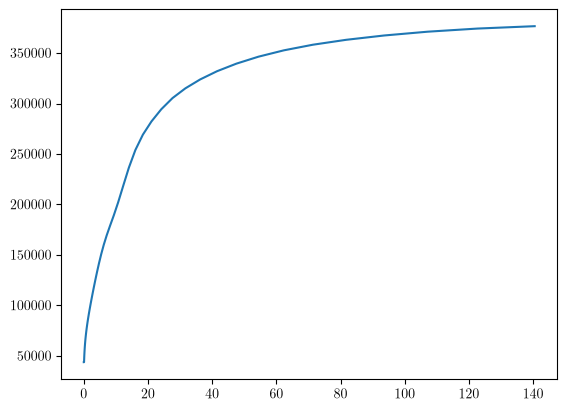

In [ ]:
par_test = [6.51412441e-01, 1.34127373e-01, 0, 0, 0, 0, 0, 0, 0]
#np.array([ 6.51412441e-01, 1.34127373e-01, 4.53257666e-01, 5.25187321e+01, 5.32980420e+02,  3.63322924e+02, -3.19786797e+00, -3.11380774e+00, -2.63301446e+00])
#

plt.plot(r, s2_real(r, par_test))

# plt.plot(rbins_c, full['c20']**2, label=r'$\sigma_r^2$')
# plt.plot(rbins_c, full['c02']**2, label=r'$\sigma_t^2$')
# plt.plot(rbins_c, full['c20']**2+full['c02']**2)


# plt.plot(rbins_c, sigma_mod(rbins_c, 355, *sig_pars)**2)

# plt.legend()

In [14]:
sigma12_gsm_at_x(5, r)[1].shape

(25,)

In [15]:
r.shape

(71,)

In [58]:
len(pars_best_joint[0])

11

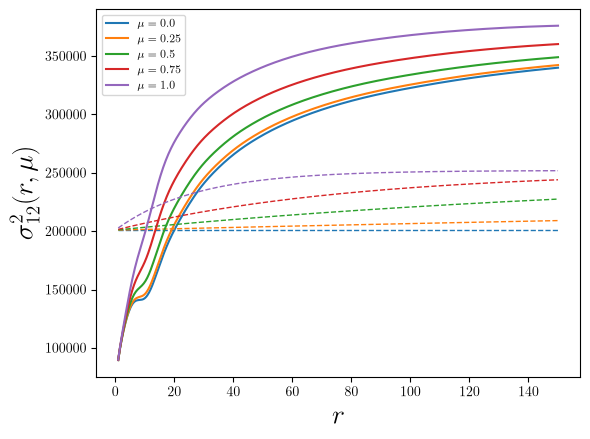

In [59]:
def sigma12_gsm(r_grid, mu, pars):
    """GSM sigma_12^2(r,mu) at fixed mu, swept over r."""
    uc = a*H/h
    gsm.compute_cumulants(*pars)
    xi_int = 1 + np.interp(r_grid, gsm.rint, gsm.xieft)
    s0     = np.interp(r_grid, gsm.rint, gsm.s0eft) / xi_int
    s2     = np.interp(r_grid, gsm.rint, gsm.s2eft) / xi_int
    v12    = v12_real(r_grid, pars)

    sigma2 = uc**2 * f_growth**2 * (s0 + 0.5*(3*mu**2 - 1)*s2) - v12**2
    return sigma2

# --- comparison ---
r_grid = np.linspace(1, 150, 500)
mu_values = [0.0, 0.25, 0.5, 0.75, 1.0]


fig, ax = plt.subplots(figsize=(6,4.5))

for i, mu in enumerate(mu_values):
    sig2_gsm = sigma12_gsm(r_grid, mu, pars_best_joint[1, :-2])
    ax.plot(r_grid, sig2_gsm, color=f'C{i}', label=fr'$\mu={mu}$')

    x_fixed = r_grid * (mu**2) / (1 + np.sqrt(1 - mu**2))
    sig2_compact = sigma_mod(x_fixed, 355, *sig_pars)**2
    ax.plot(r_grid, sig2_compact, color=f'C{i}', ls='--', lw=1)

ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\sigma_{12}^2(r,\mu)$')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

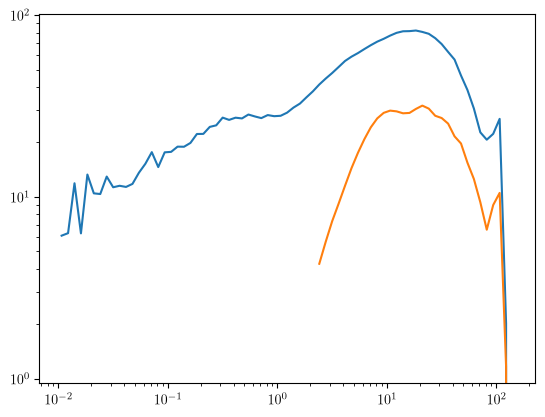

In [4]:
plt.loglog(r, r**2*xihh)
plt.loglog(r[40:], r[40:]**2*xizel_real(r[40:]))

Text(0, 0.5, '$\\frac{1+\\xi_{\\rm ZA}(r)}{1+\\xi(r)}$')

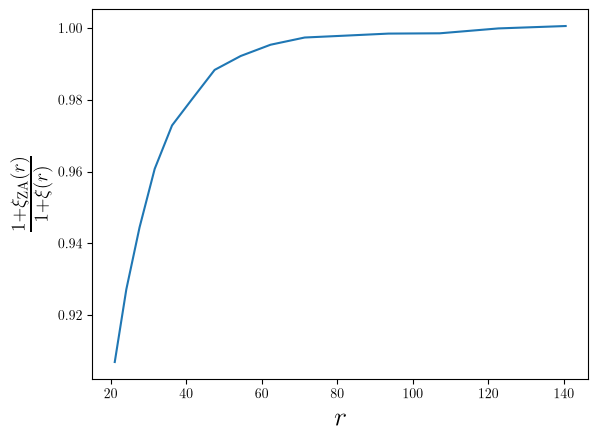

In [8]:
xizel = xizel_real(r)
mask = r > 20

ratio = (1+xizel)/(1+xihh)

plt.plot(r[mask], ratio[mask])
plt.xlabel(r'$r$')
plt.ylabel(r'$\frac{1+\xi_{\rm ZA}(r)}{1+\xi(r)}$')

In [16]:
from scipy.integrate import quad
from scipy.special import spherical_jn


# 2. Define parameters
b = 1.0          # Linear bias factor
r_test = 10.0         # Radial separation r in Mpc/h

# 3. Calculate cosmological factors
H = cosmo.Hz(redshift)  # Hubble parameter H(redshift) in km/s/Mpc

# Colossus doesn't natively expose the logarithmic growth rate f(redshift).
# We use the standard, highly accurate LambdaCDM approximation: f(redshift) ≈ Ω_m(redshift)^0.55
f = cosmo.Om(redshift)**0.55   

# 4. Define the integrand
def integrand(k, r_val, z_val):
    # Matter power spectrum P_mm(k) at redshift z
    P_mm = cosmo.matterPowerSpectrum(k, z_val, model='camb')
    
    # Spherical Bessel function j_1(kr)
    j1 = spherical_jn(1, k * r_val)
    
    return k * P_mm * j1

# 5. Integrate over wavenumber k
# Using bounds [1e-4, 100] instead of [0, ∞] is standard practice here 
# because P(k) drops off significantly at high k, and quad handles finite bounds better.
k_min = 1e-4
k_max = 100.0

integral_result, error = quad(integrand, k_min, k_max, args=(r_test, redshift), limit=1000)

# 6. Calculate the final pairwise velocity v_12(r)
v_12 = -(H * f * b / np.pi**2) * integral_result
v_12_r = -(H * f * b / np.pi**2) * np.array([  quad(integrand, k_min, k_max, args=(ri, redshift), limit=1000) for ri in r])

print(f"Radial pairwise velocity v_12(r={r_test} Mpc/h) at z={redshift}: {v_12:.2f} km/s")

Radial pairwise velocity v_12(r=10.0 Mpc/h) at z=0.1938872970391594: -175.00 km/s


In [17]:

from colossus.lss import mass_function, bias



# 2. Define the sample parameters
z = redshift
mdef = 'vir'
M_min = 1e13  # Minimum mass in M_sun/h

# Define logarithmic integration bounds
lnM_min = np.log(M_min)
lnM_max = np.log(1e16)  # Safe upper limit since n(M) drops exponentially

# 3. Define the integrands
def integrand_numerator(lnM, z_val, mdef_val):
    M = np.exp(lnM)
    # Halo mass function dn/dlnM in (h/Mpc)^3
    dndlnM = mass_function.massFunction(M, z_val, mdef=mdef_val, model='rodriguezpuebla16', q_out='dndlnM')
    # Mass-dependent halo bias b(M)
    b = bias.haloBias(M, z_val, mdef=mdef_val, model='tinker10')
    return b * dndlnM

def integrand_denominator(lnM, z_val, mdef_val):
    M = np.exp(lnM)
    # Halo mass function dn/dlnM in (h/Mpc)^3
    dndlnM = mass_function.massFunction(M, z_val, mdef=mdef_val, model='rodriguezpuebla16', q_out='dndlnM')
    return dndlnM

# 4. Perform the numerical integration
numerator, _ = quad(integrand_numerator, lnM_min, lnM_max, args=(z, mdef))
denominator, _ = quad(integrand_denominator, lnM_min, lnM_max, args=(z, mdef))

# 5. Compute the effective bias
b_eff = numerator / denominator

print(f"Effective halo bias for M_vir > {M_min:.0e} h^-1 M_sun at z={z}: {b_eff:.2f}")

Effective halo bias for M_vir > 1e+13 h^-1 M_sun at z=0.1938872970391594: 1.61


Text(0, 0.5, 'Residual')

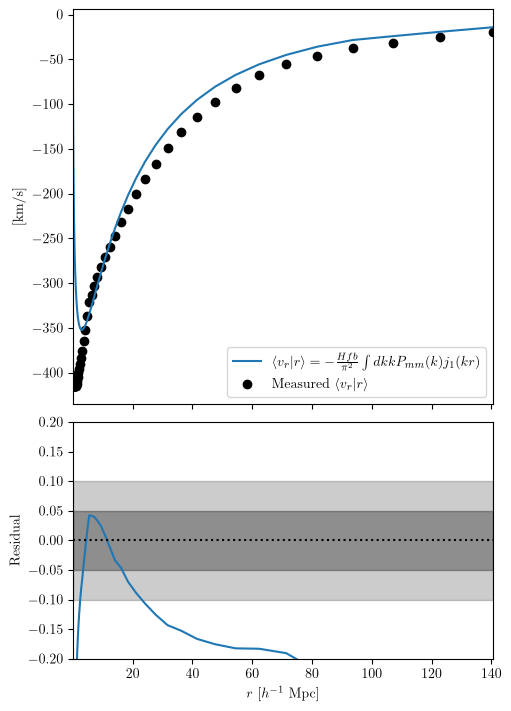

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(5, 7), layout='constrained', sharex=True, gridspec_kw={'height_ratios':[5, 3]})

plt.subplot(211)

plt.plot(r, b_eff*v_12_r[:, 0], label = r'$\langle v_{r}|r\rangle = -\frac{Hfb}{\pi^2}\int dk k P_{mm}(k)j_1(kr)$')
plt.scatter(r, v12_sim, label=r'Measured $\langle v_{r}|r\rangle$', c='k')

plt.ylabel(r'[km/s]')
plt.legend()
plt.margins(x=0)

plt.subplot(212)

plt.plot(r, (v12_sim-b_eff*v_12_r[:, 0])/(v12_sim))

plt.xlabel(r'$r$ [$h^{-1}$ Mpc]')
plt.ylim((-0.2, 0.2))
plt.axhline(0, color='k', ls=':')
plt.fill_between(r, -0.1, 0.1, color='k', alpha=0.2)
plt.fill_between(r, -0.05, 0.05, color='k', alpha=0.3)

plt.ylabel(r'Residual')

In [4]:
# fitting/plotting fcn

def xihh_fit():
    
    rmins = np.array([1, 20])#np.array([0.1, 1, 5, 16])
    xihh_bests = np.zeros((len(r), len(rmins)))
    par_bests = np.zeros((len(rmins), 9))

    for idx, rmin in enumerate(rmins) :
        
        mask = (rmin < r) & (r < 120)
        def xihh_loss(b):
            pars = b[:-1]
            xihh_in = xihh_real(r, pars)
            sigma2_soft = sigma2/np.sqrt(999) + b[-1]**2*xihh**2 
            return sum((xihh_in[mask]-xihh[mask])**2/(sigma2_soft[mask])) + sum(np.log(sigma2_soft[mask]))

        # velocipletors have 9 free parameters for hh auto corrfunc : 
        # 4 biases [b_1, b_2, b_s, b_3] (delta, delta^2, s_ij^2, delta^3)
        # 4 counter-terms : [alpha, alpha_v, alpha_s0, alpha_s2] (k^2, velocity ct, monopole and quadrupole pair-wise velocity ct)
        # 1 stochastic term [s2FoG]
        # But alpha_s0 and alpha_s2 are degenerate with others -> set to zero
        x0 = (1, 0, 0, 0, 0, 0, 0, 0, 0, 1e-3)
        #x0 = [0.5805860842963466, -1.6984844371740406, 0.5909806855955604, -0.37674584003944256, -3.830412439255513, 5.680829903647382, 0.0, 0.0, 0.0, 0.23419746609515735]

        # bounds = (
        #     (-np.inf, np.inf), # b_1
        #     (-np.inf, np.inf), # b_2
        #     (-np.inf, np.inf), # b_s
        #     (-np.inf, np.inf), # b_3
        #     (-np.inf, np.inf), # alpha for counter-term
        #     (-np.inf, np.inf), # alpha_v for velocity counter-term
        #     (0, 0),            # alpha_s0, set 0   
        #     (0, 0),            # alpha_s2, set 0
        #     (-np.inf, np.inf), # stochastic term
        #     (0, 1)             # Loss function Softening Scale
        # ) 

        bounds = [
            (0.0, 5.0),      # b_1: positive, O(1)
            (-5.0, 5.0),     # b_2
            (0.0, 0.0), #(-5.0, 5.0),     # b_s
            (0.0, 0.0), # (-5.0, 5.0),     # b_3 
            (-50.0, 50.0),   # alpha
            (-50.0, 50.0),   # alpha_v: tight enough to prevent blow-up
            (0.0, 0.0),      # alpha_s0
            (0.0, 0.0),      # alpha_s2
            (0.0, 0.0),     # s2FoG: must be non-negative physically
            (0.0, 1.0),      # eps_soft
        ]

        pars_best = minimize(xihh_loss, x0 = x0, bounds = bounds, method = 'L-BFGS-B', options={'ftol': 1e-8, 'gtol': 1e-8}).x  #Nelder-Mead
        
        print(
            f'Best-fit with {rmin:f}: \n', 
            f'  b_1 = {pars_best[0]:.3e} \t',
            f'  b_2 = {pars_best[1]:.3e} \t',
            f'  b_s = {pars_best[2]:.3e} \t',
            f'  b_3 = {pars_best[3]:.3e} \n',
            f'  alpha    = {pars_best[4]:.3e} \t',
            f'  alpha_v  = {pars_best[5]:.3e} \t',
            f'  alpha_s0 = {pars_best[6]:.3e} \t',
            f'  alpha_s2 = {pars_best[7]:.3e} \n', 
            f'  s2FoG    = {pars_best[8]:.3e} \n'
            f'  eps_soft = {pars_best[9]:.3e} \n'
        )

        print(pars_best.tolist())

        xihh_bests[:, idx] = xihh_real(r, pars_best[:-1])
        par_bests[idx] = pars_best[:-1]
   
    fig, axs = plt.subplots(2, 1, figsize=(7,6), sharex = True, gridspec_kw={'height_ratios': [5, 3], 'hspace' : 0 })
    ##############################################
    plt.subplot(211)
    plt.scatter(r, r**2*xihh, color = 'k', linewidth = 3, label ='Simulation')
    plt.plot(r, r**2*(xihh + np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, r**2*(xihh - np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')

    ## Fig 4 
    for idx, rmin in enumerate(rmins) :
        plt.plot(r, r**2*xihh_bests[:, idx], linewidth = 2, color = 'C' + str(1+idx), label = r'$r_{\rm min}=$' + f'{rmin:.1f}')
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.legend(loc = 'upper left', fontsize = 10, ncol = 2, framealpha = 0.95)
    plt.grid(True)
    #plt.ylim(0, 230)
    plt.ylim(0, max((r**2*xihh)[r > 10])*1.2)
    plt.yticks(fontsize = 20)
    plt.ylabel(r'$r^2\xi_{\rm hh}(r)$ [$h^{-2}$ Mpc$^2$]', fontsize = 20)
    plt.tight_layout()

    ##############################################
    plt.subplot(212)
    plt.plot(r, (xihh + np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (xihh - np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')

    for idx, rmin in enumerate(rmins) :
        plt.plot(r, xihh_bests[:, idx]/xihh, linewidth = 2, color = 'C' + str(1+idx))
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.ylabel('Model/Sim', fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.ylim(0.942, 1.058)

    plt.xscale('log')
    plt.xlabel(r'$r$ [$h^{-1}$ Mpc]', fontsize = 20)
    plt.xticks(fontsize = 20)
    plt.xlim(8e-1, 1.5e2)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return r, xihh_bests, rmins, par_bests

Best-fit with 1.000000: 
   b_1 = 5.733e-01 	   b_2 = -1.187e+00 	   b_s = 0.000e+00 	   b_3 = 0.000e+00 
   alpha    = 1.227e+01 	   alpha_v  = 0.000e+00 	   alpha_s0 = 0.000e+00 	   alpha_s2 = 0.000e+00 
   s2FoG    = 0.000e+00 
  eps_soft = 1.918e-02 

[0.5733461590712701, -1.1868536475954707, 0.0, 0.0, 12.265399996097122, 0.0, 0.0, 0.0, 0.0, 0.019178742763888715]
Best-fit with 20.000000: 
   b_1 = 6.008e-01 	   b_2 = -1.008e+00 	   b_s = 0.000e+00 	   b_3 = 0.000e+00 
   alpha    = 8.439e+00 	   alpha_v  = 0.000e+00 	   alpha_s0 = 0.000e+00 	   alpha_s2 = 0.000e+00 
   s2FoG    = 0.000e+00 
  eps_soft = 0.000e+00 

[0.6007950027702926, -1.0075023516154018, 0.0, 0.0, 8.438616521875517, 0.0, 0.0, 0.0, 0.0, 0.0]


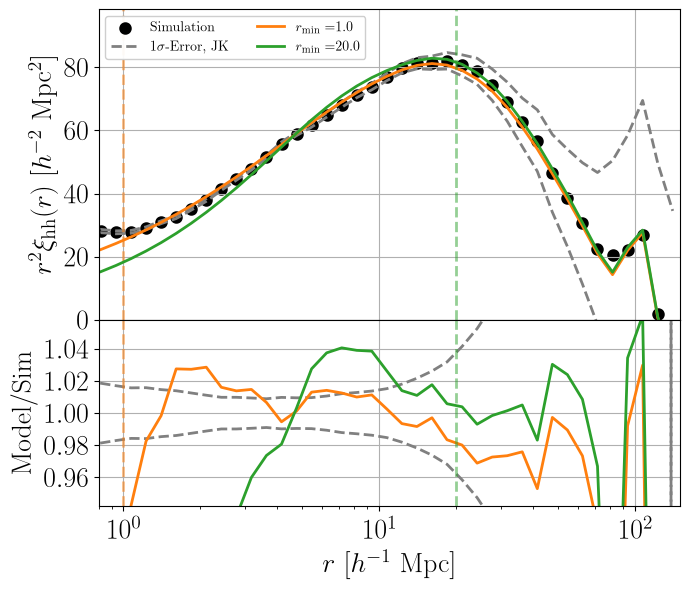

In [5]:
r, xihh_bests, rmins, par_bests = xihh_fit()

In [41]:
# load velocity moments
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

mom_dict = {}
with h5.File(save_path+"halo_moments.h5", "r") as hdf:
    for key in hdf.keys():
        mom_dict[key] = hdf[key][:] # [:] loads the data into memory as a numpy array
        
    boxsize = hdf.attrs["boxsize"]
    rbins = hdf.attrs["rbins"]

rbins_c = 0.5*(rbins[1:]+rbins[:-1])

v12_sim = np.interp(r, rbins_c, mom_dict['m10'])

In [42]:
# load jk moments 
from scipy.interpolate import RectBivariateSpline

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'


with h5.File(save_path + "halo_moments_jk.h5", "r") as hdf:
    #print(hdf.keys())
    #print(hdf.attrs.keys())

    keys = ['c02', 'c04', 'c12', 'c20', 'c22', 'c30', 'c40', 'm10']
    #print(keys)
    full       = {key: hdf["full"][key][:] for key in hdf["full"]}
    jk_samples = {key: hdf["jk_samples"][key][:] for key in hdf["jk_samples"]}
    cov        = hdf["cov"][:]
    rbins      = hdf.attrs["rbins"]
    L_box      = hdf.attrs["boxsize"]
    n_jk_1d    = hdf.attrs["n_jk_1d"]

rbins_c = 0.5*(rbins[1:]+rbins[:-1])

# restructure cov matrix 
n_jk = n_jk_1d**3
jk_matrix = np.stack([jk_samples[k] for k in keys], axis=-1)  # (n_jk, n_bins, n_moments)
mean_jk = jk_matrix.mean(axis=0)
delta = jk_matrix - mean_jk
cov = (n_jk - 1) / n_jk * np.einsum('kbi,kci->ibc', delta, delta)

v12_sim = np.interp(r, rbins_c, mom_dict['m10'])

spline = RectBivariateSpline(rbins_c, rbins_c, cov[keys.index('m10')], kx=3, ky=3)

cov_v12_sim = np.diag(spline(r, r))

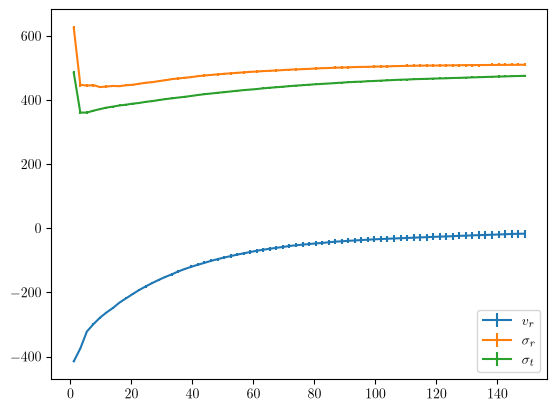

In [8]:
plt.errorbar(rbins_c, full['m10'], yerr=np.sqrt(np.diag(cov[keys.index('m10')])), label=r'$v_r$') # In km/s
plt.errorbar(rbins_c, full['c20'], yerr=np.sqrt(np.diag(cov[keys.index('c20')])), label=r'$\sigma_r$')
plt.errorbar(rbins_c, full['c02'], yerr=np.sqrt(np.diag(cov[keys.index('c02')])), label=r'$\sigma_t$')

plt.legend()

In [9]:

from matplotlib.widgets import Slider

def interactive_xihh(r, xihh, sigma2, gsm):
    """
    Sliders for all 9 GSM parameters, live-updating against measured xihh.
    r, xihh, sigma2: arrays from your HDF5 file
    gsm: your GaussianStreamingModel instance (already initialized)
    """
    def model(pars):
        gsm.compute_cumulants(*pars)
        return gsm.compute_xi_real(r, *pars)

    init = [1.463, -0.446, 0.617, -2, 12.7, -0.03, 0, 0, 0] #[0.73, 0.0, 0.0, 0.0, -20.0, 0.0, 0.0, 0.0, 0.0]
    param_names = ['b_1', 'b_2', 'b_s', 'b_3', 'alpha', 'alpha_v', 'alpha_s0', 'alpha_s2', 's2FoG']
    slider_ranges = [
        (0.1, 3.0),    # b_1
        (-2.0, 2.0),   # b_2
        (-2.0, 2.0),   # b_s
        (0.0, 0.0), #(-2.0, 2.0),   # b_3
        (-50.0, 50.0), # alpha
        (0.0, 0.0), #(-10.0, 10.0), # alpha_v
        (0.0, 0.0), #(-10.0, 10.0),    # alpha_s0 (fixed)
        (0.0, 0.0), #(-10.0, 10.0),    # alpha_s2 (fixed)
        (0.0, 0.0), #(0.0, 20.0),   # s2FoG
    ]

    fig = plt.figure(figsize=(10, 8))
    ax_top = fig.add_axes([0.10, 0.52, 0.85, 0.43])
    ax_bot = fig.add_axes([0.10, 0.32, 0.85, 0.18], sharex=ax_top)

    # Draw simulation data (static)
    ax_top.scatter(r, r**2 * xihh, color='k', s=15, label='Simulation', zorder=3)
    ax_top.fill_between(r, r**2*(xihh - np.sqrt(sigma2)), r**2*(xihh + np.sqrt(sigma2)),
                        color='gray', alpha=0.3, label=r'1$\sigma$ JK')
    ax_bot.fill_between(r, 1 - np.sqrt(sigma2)/np.abs(xihh), 1 + np.sqrt(sigma2)/np.abs(xihh),
                        color='gray', alpha=0.3)
    ax_bot.axhline(1.0, color='gray', lw=1)

    xi_model = model(init)
    line_top, = ax_top.plot(r, r**2 * xi_model, color='C1', lw=2, label='Model')
    line_bot, = ax_bot.plot(r, xi_model / xihh, color='C1', lw=2)

    ax_top.set_xscale('log'); ax_top.set_xlim(8e-1, 1.2e2)
    ax_top.set_ylabel(r'$r^2\xi_{\rm hh}(r)$', fontsize=13)
    ax_top.legend(fontsize=11); ax_top.grid(True)
    ax_bot.set_xscale('log'); ax_bot.set_xlabel(r'$r$ [h$^{-1}$ Mpc]', fontsize=13)
    ax_bot.set_ylabel('Model/Sim', fontsize=11); ax_bot.set_ylim(0.94, 1.06); ax_bot.grid(True)

    # Build sliders (skip fixed params)
    sliders = []
    slider_bottom = 0.28
    for i, (name, (lo, hi)) in enumerate(zip(param_names, slider_ranges)):
        ax_s = fig.add_axes([0.15, slider_bottom - i*0.028, 0.70, 0.018])
        if lo == hi:  # fixed parameter
            s = Slider(ax_s, name, -1, 1, valinit=0, color='lightgray')
            s.set_active(False)
        else:
            s = Slider(ax_s, name, lo, hi, valinit=init[i])
        sliders.append(s)

    def update(_):
        pars = [s.val for s in sliders]
        try:
            xi_new = model(pars)
            line_top.set_ydata(r**2 * xi_new)
            line_bot.set_ydata(xi_new / xihh)
            ax_top.set_ylim(0, max((r**2 * xihh)[r > 10]) * 1.2)
        except Exception:
            pass
        fig.canvas.draw_idle()

    for s in sliders:
        s.on_changed(update)

    plt.show()


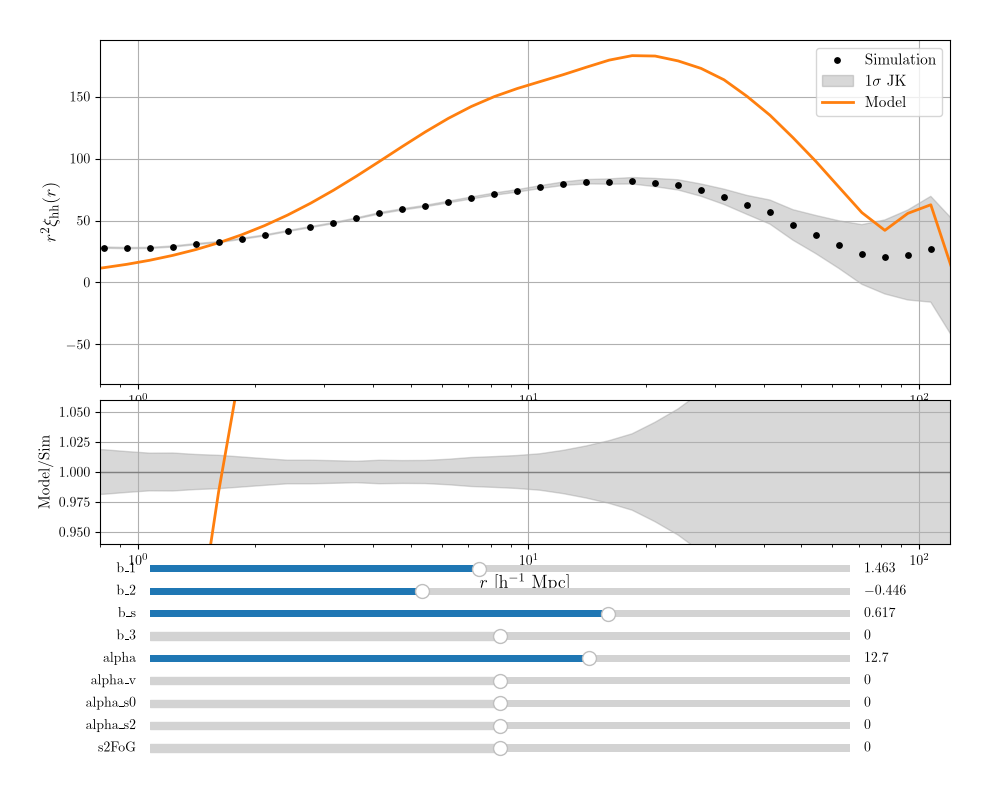

In [18]:
%matplotlib widget

interactive_xihh(r, xihh, sigma2, gsm)

plt.close()

In [48]:
# joint fits to xi_hh and v_12

def joint_fit(r, xihh, v12_sim, sigma2, sigma_v2, x0):
    # Only fit on perturbative scales!
    rmins = np.array([5, 20]) 

    pars_best = np.zeros((len(rmins), 11))  # 9 parameters + softening scale
    
    for idx, rmin in enumerate(rmins):
        mask = ((rmin < r) & (r < 150))
        
        def joint_loss(b):
            pars = b[:-2] # Your 9 parameters
            
            # 1. Evaluate both models using the parameters
            # (Assuming you wrapped the GSM extraction we discussed previously)
            xihh_model = xihh_real(r, pars)
            v12_model  = v12_real(r, pars) # You need a function that returns the v12 model
            
            # 2. Chi-squared for density
            sigma2_soft_xi = sigma2[mask] + b[-2]**2*xihh[mask]**2
            chi2_xi = sum((xihh_model[mask] - xihh[mask])**2/ sigma2_soft_xi )#
            
            # 3. Chi-squared for mean velocity
            sigma2_soft_v = sigma_v2[mask] + b[-1]**2*v12_sim[mask]**2
            chi2_v12 = sum((v12_model[mask] - v12_sim[mask])**2/ sigma2_soft_v )# 
            
            # 4. Total Loss
            # (Note: omitting the log(sigma) term here if errors are fixed, 
            # otherwise keep your softening term for both)
            return chi2_xi + chi2_v12

        # Set alpha_s0 and alpha_s2 to fixed 0 bounds since they only affect dispersion
        bounds = [
            (0.0, 5.0),      # b_1
            (0.0, 5.0**2),     # b_2
            (0.0, 5.0**2), #(-5.0, 5.0),     # b_s allow to vary for \sigma_12 check above
            (0.0, 0.0), #(-5.0, 5.0),     # b_3 (0.0, 0.0), #
            (0.0, 0.0), #(-50.0, 50.0),   # alpha
            (0.0, 0.0), #(-50.0, 50.0),   # alpha_v 
            (0.0, 0.0),      # alpha_s0 (Fixed)
            (0.0, 0.0),      # alpha_s2 (Fixed)
            (0.0, 0.0),     # s2FoG
            (0.0, 1.0),      # eps_soft_xi
            (0.0, 1.0),      # eps_soft_v (new par!)
        ]

        pars_best[idx] = minimize(joint_loss, 
                                  x0=x0, 
                                  bounds=bounds, 
                                  method='nelder-mead', #'nelder-mead', #'L-BFGS-B' 
                                  options={'fatol': 1e-16, 'xatol': 1e-16}, #{'ftol': 1e-8, 'gtol': 1e-8}, #
                                  ).x

    return pars_best


def plot_joint_fits(r, xihh, v12_sim, sigma2, sigma_v2,  pars_best):


    xihh_bests = np.array([xihh_real(r, p[:-2]) for p in pars_best]).T
    v12_bests = np.array([v12_real(r, p[:-2]) for p in pars_best]).T

    fig, axs = plt.subplots(2, 2, figsize=(14, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1],})

    plt.subplot(221)
    plt.scatter(r, r**2*xihh, color = 'k', linewidth = 3, label ='Simulation')
    plt.plot(r, r**2*(xihh + np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, r**2*(xihh - np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')

    for idx, rmin in enumerate(rmins) :
        
        style = '-'
        if idx > 0:
            style = '--'

        plt.plot(r, r**2*xihh_bests[:, idx], linewidth = 2, color = 'C' + str(1+idx), label = r'$r_{\rm min}=$' + f'{rmin:.1f}')
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.legend(loc = 'upper left', fontsize = 10, ncol = 2, framealpha = 0.95)
    plt.grid(True)
    #plt.ylim(0, 230)
    plt.ylim(0, max((r**2*xihh)[r > 10])*1.2)
    plt.yticks(fontsize = 20)
    plt.ylabel(r'$r^2\xi_{\rm hh}(r)$ [$h^{-2}$ Mpc$^2$]', fontsize = 20)
    plt.tight_layout()

    ##############################################
    plt.subplot(223)
    plt.plot(r, (xihh + np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (xihh - np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')

    for idx, rmin in enumerate(rmins) :
        plt.plot(r, xihh_bests[:, idx]/xihh, linewidth = 2, color = 'C' + str(1+idx))
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.ylabel('Model/Sim', fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.ylim(0.9, 1.1)

    plt.xscale('log')
    plt.xlabel(r'$r$ [$h^{-1}$ Mpc]', fontsize = 20)
    plt.xticks(fontsize = 20)
    plt.xlim(8e-1, 1.4e2)

    plt.grid(True)
    plt.tight_layout()

    plt.subplot(222)
    plt.scatter(r, v12_sim, color = 'k', linewidth = 3, label ='Simulation')
    plt.plot(r, (v12_sim + np.sqrt(sigma_v2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (v12_sim - np.sqrt(sigma_v2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')

    
    ## Fig 4 
    for idx, rmin in enumerate(rmins) :
        plt.plot(r, v12_bests[:, idx], linewidth = 2, color = 'C' + str(1+idx), label = r'$r_{\rm min}=$' + f'{rmin:.1f}')
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.legend(loc = 'upper left', fontsize = 10, ncol = 2, framealpha = 0.95)
    plt.grid(True)
    #plt.ylim(0, 230)
    plt.ylim(-500, 100)
    plt.yticks(fontsize = 20)
    plt.ylabel(r'$\langle v_r|r\rangle$ [km/s]', fontsize = 20)
    plt.tight_layout()

    ##############################################
    plt.subplot(224)
    plt.plot(r, (v12_sim + np.sqrt(sigma_v2))/v12_sim, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (v12_sim - np.sqrt(sigma_v2))/v12_sim, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')


    for idx, rmin in enumerate(rmins) :
        plt.plot(r, v12_bests[:, idx]/v12_sim, linewidth = 2, color = 'C' + str(1+idx))
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.ylabel('Model/Sim', fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.ylim(0.85, 1.15)

    plt.xscale('log')
    plt.xlabel(r'$r$ [$h^{-1}$ Mpc]', fontsize = 20)
    plt.xticks(fontsize = 20)
    plt.xlim(8e-1, 1.4e2)

    plt.grid(True)
    plt.tight_layout()

In [9]:
par_bestss = np.append(par_bests, np.array([[1e-3], [1e-3]]), axis=1)

par_bestss.shape

(2, 10)

In [49]:
pars_best_joint = joint_fit(r, 
                            xihh, 
                            v12_sim, 
                            sigma2, 
                            cov_v12_sim, 
                            x0=[1, 0, 0, 0, 0, 0, 0, 0, 0, 1e-3, 1e-3],
                            ) 
#  par_bestss[1] 
# [0.57, -1, 0, 0, 0, 0, 0, 0, 0, 1e-3]
# [ 5.71038e-01, -9.99998558e-01,  0.00e+00, 0.00e+00,  6.74084449e-08,  1.17496505e-05, 0.00e+00,  0.00e+00,  0.00e+00, 1.00e-03]

In [11]:
pars_best_joint

array([[ 0.59294764, -0.30099432,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.0387671 ,
         0.73917328],
       [ 0.65001633,  0.1780316 ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ]])

In [50]:
pars_best_joint

array([[6.22909597e-01, 0.00000000e+00, 1.06741334e-15, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [6.38095143e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 1.00000000e+00]])

In [62]:
bf_pars[:2]

array([0.66394196, 0.12078237])

In [74]:
plt.close()

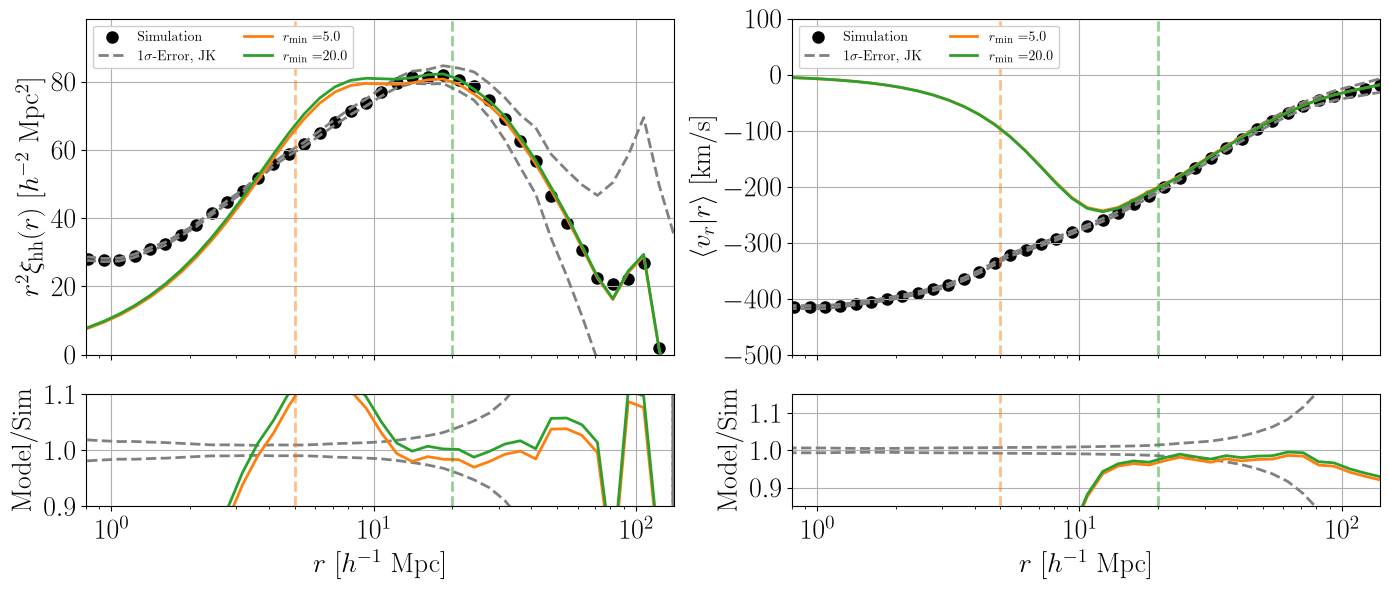

In [47]:
%matplotlib inline
rmins = np.array([5, 20]) 
plot_joint_fits(r, xihh, v12_sim, sigma2, cov_v12_sim, pars_best_joint)

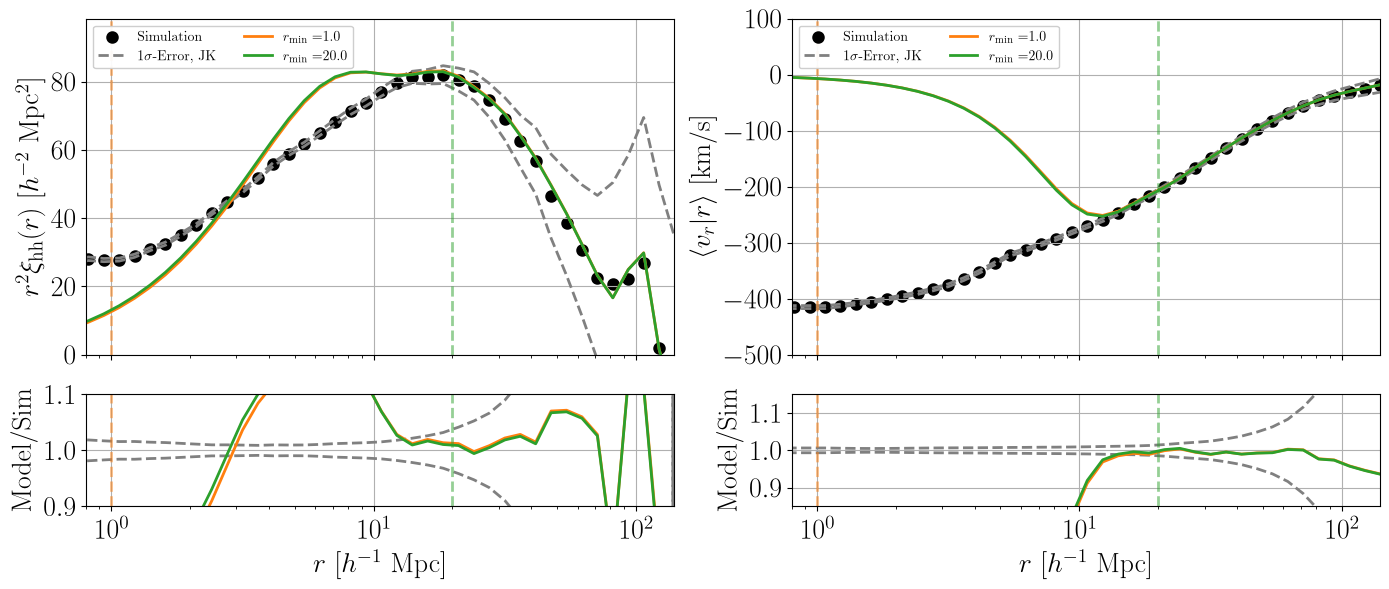

In [94]:
plot_joint_fits(r, xihh, v12_sim, sigma2, cov_v12_sim, np.array([np.concatenate([mean_params[:2], np.zeros(9)]), np.concatenate([[0.64998712, 0.17870901], np.zeros(9)])]))

In [59]:
pars_best_joint.shape

(2, 11)

In [60]:
bf_pars.shape

(6,)

In [133]:
# save predictions and correpsonding pars

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/LPT/'

with h5.File(save_path+'lpt_2par_joint_fit.hdf5', 'w') as hdf:
    hdf.create_dataset('r_cens', data=r)
    hdf.create_dataset('xi_hh', data=xihh_real(r, pars_best_joint[1][:-2])) 
    hdf.create_dataset('v12', data=v12_real(r, pars_best_joint[1][:-2]))
    hdf.create_dataset('pars', data=pars_best_joint[1][:-2])

    hdf.attrs['rmin'] = 20

In [10]:
par_bests

array([[ 0.59014229, -2.30888461,  2.64302889,  0.        ,  1.51628299,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.61776537, -2.5501598 ,  1.90176523,  0.        , -6.89562792,
         0.        ,  0.        ,  0.        ,  0.        ]])

In [11]:

from matplotlib.widgets import Slider

def plot_interactive_joint_fits(r, xihh, v12_sim, sigma2, init_pars):
    rmin = 20.0
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex='col', gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    plt.subplots_adjust(bottom=0.45) 
    
    p0 = init_pars[:9] 
    xihh_init = xihh_real(r, p0)
    v12_init = v12_real(r, p0)

    # Top-Left: xi_hh
    axs[0, 0].scatter(r, r**2*xihh, color='k', linewidth=3, label='Simulation')
    axs[0, 0].plot(r, r**2*(xihh + np.sqrt(sigma2)), color='gray', lw=2, ls='--')
    axs[0, 0].plot(r, r**2*(xihh - np.sqrt(sigma2)), color='gray', lw=2, ls='--', label='1$\sigma$-Error')
    line_xi, = axs[0, 0].plot(r, r**2*xihh_init, lw=2, color='C1', label=r'$r_{\rm min}=$' + f'{rmin:.1f}')
    axs[0, 0].axvline(rmin, color='C1', lw=2, alpha=0.5, ls='--')
    axs[0, 0].legend(loc='upper left', fontsize=10, ncol=2, framealpha=0.95)
    axs[0, 0].grid(True)
    axs[0, 0].set_ylim(0, max((r**2*xihh)[r > 10])*1.2)
    axs[0, 0].set_ylabel(r'$r^2\xi_{\rm hh}(r)$ [$h^{-2}$ Mpc$^2$]', fontsize=15)

    # Bottom-Left: xi_hh ratio
    axs[1, 0].plot(r, (xihh + np.sqrt(sigma2))/xihh, color='gray', lw=2, ls='--')
    axs[1, 0].plot(r, (xihh - np.sqrt(sigma2))/xihh, color='gray', lw=2, ls='--')
    line_xi_rat, = axs[1, 0].plot(r, xihh_init/xihh, lw=2, color='C1')
    axs[1, 0].axvline(rmin, color='C1', lw=2, alpha=0.5, ls='--')
    axs[1, 0].set_ylabel('Model/Sim', fontsize=15)
    axs[1, 0].set_ylim(0.942, 1.058)
    axs[1, 0].set_xscale('log')
    axs[1, 0].set_xlabel(r'$r$ [$h^{-1}$ Mpc]', fontsize=15)
    axs[1, 0].set_xlim(1e-1, 1.4e2)
    axs[1, 0].grid(True)

    # Top-Right: v12
    axs[0, 1].scatter(r, v12_sim, color='k', linewidth=3, label='Simulation')
    line_v12, = axs[0, 1].plot(r, v12_init, lw=2, color='C1', label=r'$r_{\rm min}=$' + f'{rmin:.1f}')
    axs[0, 1].axvline(rmin, color='C1', lw=2, alpha=0.5, ls='--')
    axs[0, 1].legend(loc='upper left', fontsize=10, ncol=2, framealpha=0.95)
    axs[0, 1].grid(True)
    axs[0, 1].set_ylim(-500, 100)
    axs[0, 1].set_ylabel(r'$v_{12}(r)$ [km/s]', fontsize=15) 

    # Bottom-Right: v12 ratio
    line_v12_rat, = axs[1, 1].plot(r, v12_init/v12_sim, lw=2, color='C1')
    axs[1, 1].axvline(rmin, color='C1', lw=2, alpha=0.5, ls='--')
    axs[1, 1].set_ylabel('Model/Sim', fontsize=15)
    axs[1, 1].set_ylim(0.942, 1.058)
    axs[1, 1].set_xscale('log')
    axs[1, 1].set_xlabel(r'$r$ [$h^{-1}$ Mpc]', fontsize=15)
    axs[1, 1].set_xlim(1e-1, 1.4e2)
    axs[1, 1].grid(True)

    # Sliders
    axcolor = 'lightgoldenrodyellow'
    slider_axes = [plt.axes([0.1, 0.38 - i*0.035, 0.8, 0.02], facecolor=axcolor) for i in range(9)]
    
    sliders = []
    labels = ['b_1', 'b_2', 'b_s', 'b_3', 'alpha', 'alpha_v', 'alpha_s0', 'alpha_s2', 's2FoG']
    mins = [0, -10, -10, -10, -100, -100, -100, -100, 0]
    maxs = [5,  10,  10,  10,  100,  100,  100,  100, 100]
    
    for i in range(9):
        s = Slider(slider_axes[i], labels[i], mins[i], maxs[i], valinit=p0[i])
        sliders.append(s)

    def update(val):
        pars = [s.val for s in sliders]
        new_xihh = xihh_real(r, pars)
        new_v12 = v12_real(r, pars)
        
        line_xi.set_ydata(r**2 * new_xihh)
        line_xi_rat.set_ydata(new_xihh / xihh)
        line_v12.set_ydata(new_v12)
        line_v12_rat.set_ydata(new_v12 / v12_sim)
        
        fig.canvas.draw_idle()

    for s in sliders:
        s.on_changed(update)

    plt.show()
    
    return sliders # Returning sliders ensures they aren't garbage collected

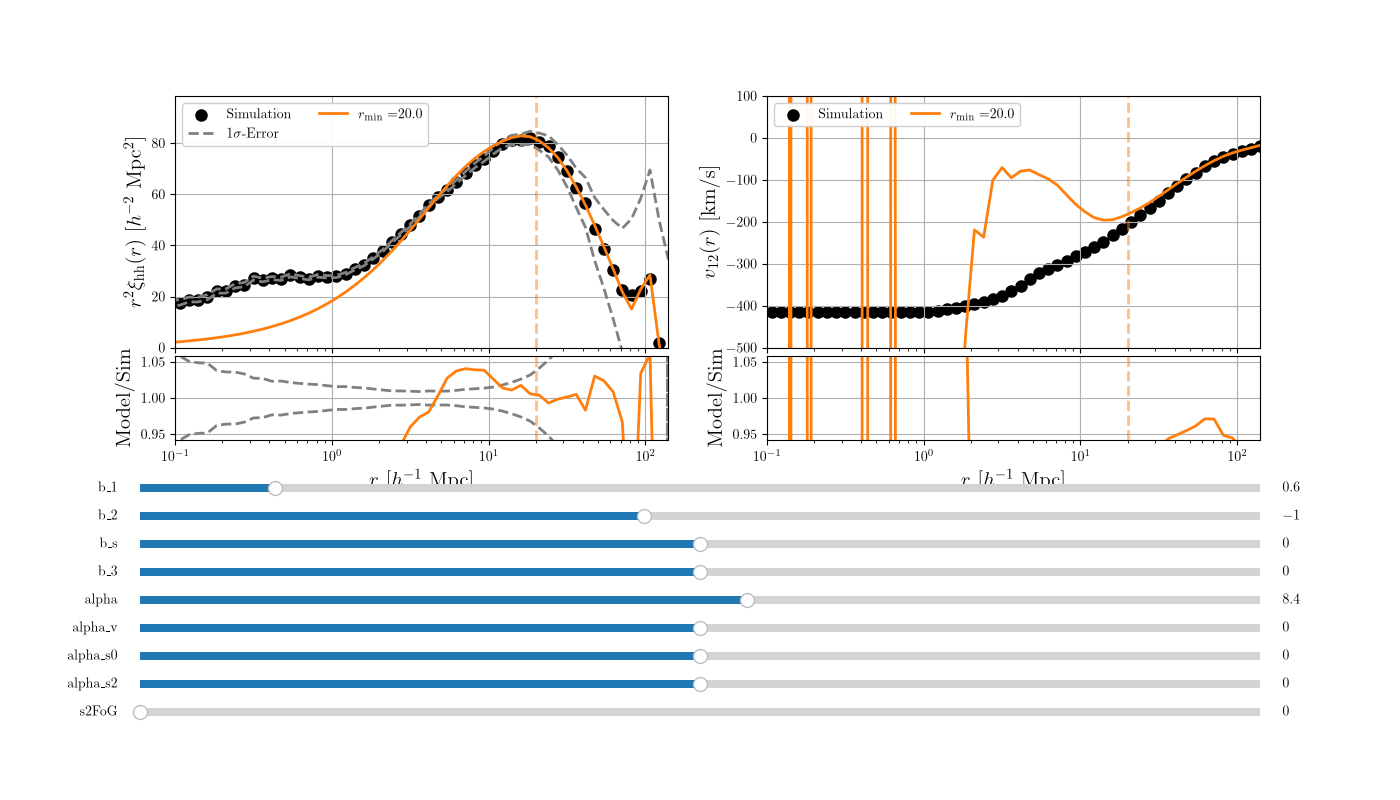

In [68]:
%matplotlib widget

plot_interactive_joint_fits(r, xihh, v12_sim, sigma2, par_bestss[1])

In [134]:
plt.close()

In [13]:
# define mu bins

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/s_mu_xi_hh.hdf5'

hdf = h5.File(save_path)

mu_bins = hdf['mu_edges'][()]
mu_bins_c = 0.5*(mu_bins[1:]+mu_bins[:-1])

In [14]:
# re-fit compact model to multipoles, varying LPT and compact parameters simultaneously


comp_bf_pars = np.array([  0.5310972 ,  55.33533501, 190.03086941,   8.22406535]) # from compact joint fit

lpt_p0 = np.array(pars_best_joint[1][:2])  # b_1, b_2 starting point

p0 = np.concatenate([lpt_p0, comp_bf_pars])

lpt_bounds = np.array([
            (0.0, 5.0),      # b_1
            (-5.0, 5.0),     # b_2
        ]).T

compact_bounds = np.array([
            (np.min((0, np.sign(par)*np.inf)), np.max((0, np.sign(par)*np.inf))) for par in comp_bf_pars
        ]).T

Bounds = np.concatenate([lpt_bounds, compact_bounds], axis=1)

def residuals(params, mono_sim, quad_sim, hexa_sim, w_mono, w_quad, w_hexa, mask):
    lpt_pars = params[:2]
    compact_pars = params[2:]

    lpt_params = np.concatenate([lpt_pars, np.zeros(7)])

    xir = xihh_real(rbins_c, lpt_params)
    xi_spline = UnivariateSpline(rbins_c, xir, s=0)

    v12 = v12_real(rbins_c, lpt_params)
    mean_vr_interp = UnivariateSpline(rbins_c, v12, s=0)

    def compact_pdf(v, rp, rl):
        uc = h/a/H # unit conversion
        r = np.sqrt(rp**2 + rl**2)
        x = r - rp
        return (1/uc) * Pv_compact(v/uc, rp, rl, mean_vr_interp, pars=compact_pars)

    s_mu = simps_integrate(
        s_c=rbins_c, mu_c=mu_bins_c,
        twopcf_function=xi_spline,
        los_pdf_function=compact_pdf,
        limit=160,
        epsilon=0.01,
        n=100,
    )
    mono = tpcf_multipole(s_mu, mu_bins, order=0)
    quad = tpcf_multipole(s_mu, mu_bins, order=2)
    hexa = tpcf_multipole(s_mu, mu_bins, order=4)

    return np.concatenate([
        ((mono - mono_sim) / w_mono)[mask],
        ((quad - quad_sim) / w_quad)[mask],
        ((hexa - hexa_sim) / w_hexa)[mask],
    ])

In [15]:
# load JK estimates from pycorr

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/xi_smu_hh_pycorr.hdf5'


with h5.File(save_path, 'r') as hdf:
    xi_ell = hdf['xi_ell'][()]
    xi_ell_cov = hdf['xi_ell_cov'][()]
    s_cens = hdf['s_cens'][()]

nells = 3
xi_ell_std = np.array(np.array_split(np.diag(xi_ell_cov)**0.5, nells))

In [16]:
monopole, quadrupole, hexadecapole = xi_ell
w_mono, w_quad, w_hexa = xi_ell_std

result = least_squares(
    residuals, p0, bounds=Bounds,
    args=(monopole, quadrupole, hexadecapole, w_mono, w_quad, w_hexa, (rbins_c>20)),
    verbose=2,
    max_nfev=300,
    ftol=1e-16, 
    gtol=1e-16,
)

bf_pars = result.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.8069e+01                                    5.42e+01    
       1              7         3.4934e+01      3.14e+00       3.99e-01       1.94e+01    
       2             10         3.4601e+01      3.33e-01       4.24e-02       2.09e+01    
       3             12         3.4444e+01      1.57e-01       2.16e-02       2.08e+01    
       4             13         3.4158e+01      2.86e-01       4.46e-02       1.75e+01    
       5             16         3.4126e+01      3.22e-02       5.37e-03       1.72e+01    
       6             17         3.4064e+01      6.16e-02       1.09e-02       1.64e+01    
       7             20         3.4057e+01      7.46e-03       1.34e-03       1.63e+01    
       8             22         3.4053e+01      3.71e-03       6.71e-04       1.62e+01    
       9             23         3.4046e+01      7.37e-03       1.35e-03       1.61e+01    

In [94]:
result.status

3

In [88]:
len(monopole)

70

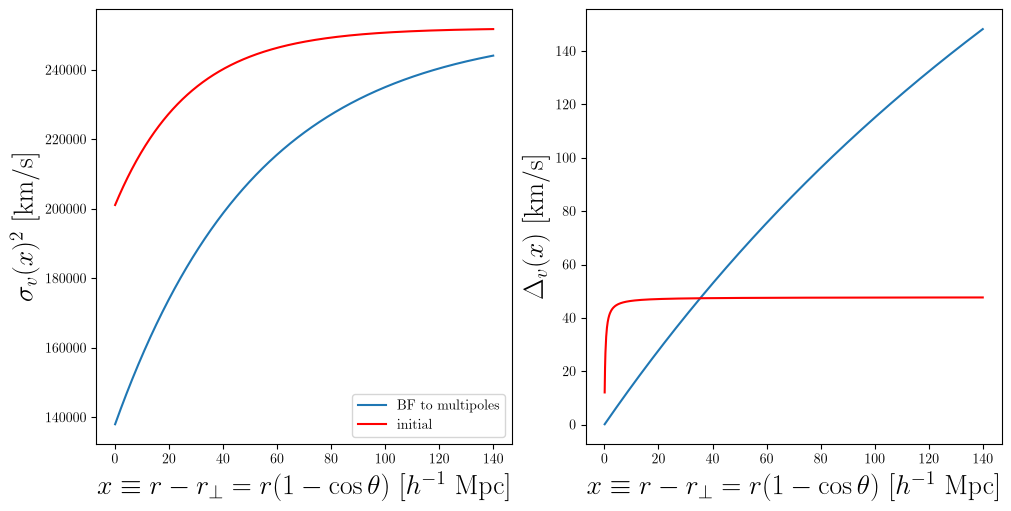

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

xs = np.linspace(0.1, 140, 1000)

ax[0].plot(xs, sigma_mod(xs, 355, *(mean_params[2:-3])[:2])**2, label='BF to multipoles')
ax[0].plot(xs, sigma_mod(xs, 355, *sig_pars)**2, c='r', label='initial')
ax[0].set_ylabel(r'$\sigma_v(x)^2$ [km/s]')
ax[0].set_xlabel(r'$x\equiv r-r_\perp = r(1-\cos\theta)$ [$h^{-1}$ Mpc]')

ax[1].plot(xs, delta_mod(xs, *(mean_params[2:-3])[2:]))
ax[1].plot(xs, delta_mod(xs, *del_pars), c='r')
ax[1].set_ylabel(r'$\Delta_v(x)$ [km/s]')
ax[1].set_xlabel(r'$x\equiv r-r_\perp = r(1-\cos\theta)$ [$h^{-1}$ Mpc]')

ax[0].legend()

In [58]:
bf_pars

array([6.63941961e-01, 1.20782375e-01, 1.00026051e+00, 5.53680910e+01,
       1.89597992e+02, 8.24072587e+00])

In [57]:
p0

array([6.49987116e-01, 1.78709011e-01, 5.31097200e-01, 5.53353350e+01,
       1.90030869e+02, 8.22406535e+00])

In [45]:
np.exp(map_params[-3:])*100

array([6.05018242, 5.24983145, 4.53659578])

In [48]:
# check bf

lpt_params = np.concatenate([mean_params[:2], np.zeros(7)])

xir = xihh_real(rbins_c, lpt_params)
xi_spline = UnivariateSpline(rbins_c, xir, s=0)

v12 = v12_real(rbins_c, lpt_params)
mean_vr_interp = UnivariateSpline(rbins_c, v12, s=0)

def compact_pdf(v, rp, rl):
    uc = h/a/H # unit conversion
    r = np.sqrt(rp**2 + rl**2)
    return (1/uc) * Pv_compact(v/uc, rp, rl, mean_vr_interp, pars=mean_params[2:-3])

compact_BF_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=xi_spline,
    los_pdf_function=compact_pdf,
    limit=160, 
    epsilon=0.01,
    n=100,
)

compact_BF_monopole = tpcf_multipole(
    compact_BF_s_mu,
    mu_bins, 
    order=0
)
compact_BF_quadrupole = tpcf_multipole(
    compact_BF_s_mu, 
    mu_bins, 
    order=2
)
compact_BF_hexadecapole = tpcf_multipole(
    compact_BF_s_mu, 
    mu_bins, 
    order=4)

In [33]:
# mono_bf
lpt_params = np.concatenate([mono_mean_params[:2], np.zeros(7)])

xir = xihh_real(rbins_c, lpt_params)
xi_spline = UnivariateSpline(rbins_c, xir, s=0)

v12 = v12_real(rbins_c, lpt_params)
mean_vr_interp = UnivariateSpline(rbins_c, v12, s=0)

def compact_pdf(v, rp, rl):
    uc = h/a/H # unit conversion
    r = np.sqrt(rp**2 + rl**2)
    return (1/uc) * Pv_compact(v/uc, rp, rl, mean_vr_interp, pars=mono_mean_params[2:-1])

compact_mono_BF_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=xi_spline,
    los_pdf_function=compact_pdf,
    limit=160, 
    epsilon=0.01,
    n=100,
)

compact_mono_BF_monopole = tpcf_multipole(
    compact_mono_BF_s_mu,
    mu_bins, 
    order=0
)
compact_mono_BF_quadrupole = tpcf_multipole(
    compact_mono_BF_s_mu, 
    mu_bins, 
    order=2
)
compact_mono_BF_hexadecapole = tpcf_multipole(
    compact_mono_BF_s_mu, 
    mu_bins, 
    order=4)

In [43]:
# mono and quad bf
lpt_params = np.concatenate([mono_quad_mean_params[:2], np.zeros(7)])

xir = xihh_real(rbins_c, lpt_params)
xi_spline = UnivariateSpline(rbins_c, xir, s=0)

v12 = v12_real(rbins_c, lpt_params)
mean_vr_interp = UnivariateSpline(rbins_c, v12, s=0)

def compact_pdf(v, rp, rl):
    uc = h/a/H # unit conversion
    r = np.sqrt(rp**2 + rl**2)
    return (1/uc) * Pv_compact(v/uc, rp, rl, mean_vr_interp, pars=mono_quad_mean_params[2:-2])

compact_mono_quad_BF_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=xi_spline,
    los_pdf_function=compact_pdf,
    limit=160, 
    epsilon=0.01,
    n=100,
)

compact_mono_quad_BF_monopole = tpcf_multipole(
    compact_mono_quad_BF_s_mu,
    mu_bins, 
    order=0
)
compact_mono_quad_BF_quadrupole = tpcf_multipole(
    compact_mono_quad_BF_s_mu, 
    mu_bins, 
    order=2
)
compact_mono_quad_BF_hexadecapole = tpcf_multipole(
    compact_mono_quad_BF_s_mu, 
    mu_bins, 
    order=4)

In [23]:
# initial 


lpt_params_ini = np.concatenate([[0.65001633,  0.1780316], np.zeros(7)])

xir_mod = xihh_real(rbins_c, lpt_params_ini)
xi_spline = UnivariateSpline(rbins_c, xir_mod, s=0)

v12_mod = v12_real(rbins_c, lpt_params_ini)
mean_vr_spline = UnivariateSpline(rbins_c, v12_mod, s=0)

uc = h/a/H # unit conversion

compact = lambda v, rp, rl: (1/uc)*Pv_compact(v/uc, rp, rl, mean_vr_spline)

compact_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=xi_spline,
    los_pdf_function=compact,
    limit=160, 
    #epsilon=0.01,
    n=60,
)

compact_monopole = tpcf_multipole(
    compact_s_mu,
    mu_bins, 
    order=0
)
compact_quadrupole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=2
)
compact_hexadecapole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=4)

Text(0.5, 0.98, 'MDPL2 halos: streaming model with LPT ($\\xi^R, \\langle v_r|r\\rangle$) + compact ($P(v_{\\rm los}|r_\\perp, r_{\\rm los})$) inputs')

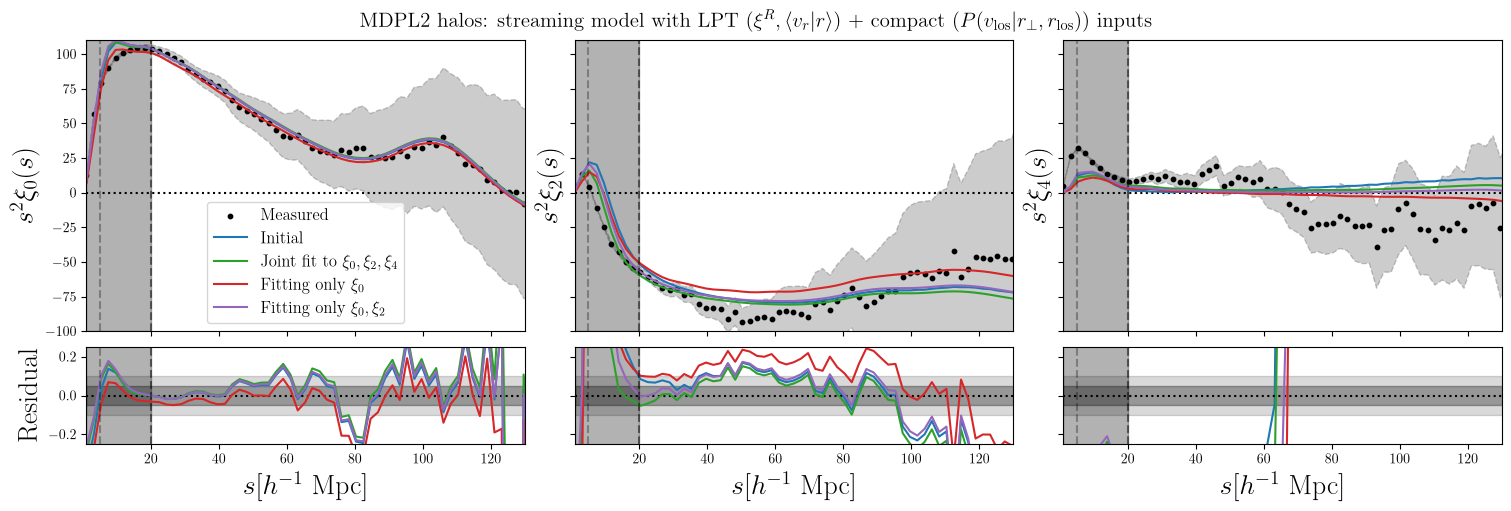

In [49]:
fig, axes = plot_multipoles_n_residuals(rbins_c, xi_ell, errs=None, preds=[compact_monopole, compact_quadrupole, compact_hexadecapole], label='Initial',)

compact_BF_multipoles = [compact_BF_monopole, compact_BF_quadrupole, compact_BF_hexadecapole]
compact_mono_BF_multipoles = [compact_mono_BF_monopole, compact_mono_BF_quadrupole, compact_mono_BF_hexadecapole]
compact_mono_quad_BF_multipoles = [compact_mono_quad_BF_monopole, compact_mono_quad_BF_quadrupole, compact_mono_quad_BF_hexadecapole]


multipoles = xi_ell

for i, lm in enumerate(compact_BF_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*lm, label=r'Joint fit to $\xi_0, \xi_2, \xi_4$', color='C2')

    axes[1, i].plot(rbins_c, (lm-multipoles[i])/(np.abs(multipoles[i])+1e-8), c='C2') #xi_ell_std[i] 

    axes[0, i].plot(rbins_c, rbins_c**2*compact_mono_BF_multipoles[i], label=r'Fitting only $\xi_0$', color='C3')

    axes[1, i].plot(rbins_c, (compact_mono_BF_multipoles[i]-multipoles[i])/(np.abs(multipoles[i])+1e-8), c='C3') #xi_ell_std[i] 

    axes[0, i].plot(rbins_c, rbins_c**2*compact_mono_quad_BF_multipoles[i], label=r'Fitting only $\xi_0, \xi_2$', color='C4')

    axes[1, i].plot(rbins_c, (compact_mono_quad_BF_multipoles[i]-multipoles[i])/(np.abs(multipoles[i])+1e-8), c='C4') #xi_ell_std[i] 

    axes[0, i].axvline(20, c='k', alpha=0.5, ls='--')
    axes[1, i].axvline(20, c='k', alpha=0.5, ls='--')

    axes[0, i].axvline(5, c='k', alpha=0.3, ls='--')
    axes[1, i].axvline(5, c='k', alpha=0.3, ls='--')

    axes[0, i].fill_betweenx(np.array([-100, 110]), 1, 20, color='k', alpha=0.3)
    axes[1, i].fill_betweenx(np.array([-100, 110]), 1, 20, color='k', alpha=0.3)

    axes[0, i].fill_between(rbins_c, rbins_c**2*(multipoles[i] + xi_ell_std[i]), rbins_c**2*(multipoles[i] - xi_ell_std[i]), color='k', alpha=0.2, ls='--')


axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 130))
axes[0, 1].set_xlim((1, 130))
axes[0, 2].set_xlim((1, 130))

axes[0, 0].legend(loc='lower center', fontsize=12)

fig.suptitle(r'MDPL2 halos: streaming model with LPT ($\xi^R, \langle v_r|r\rangle$) + compact ($P(v_{\rm los}|r_\perp, r_{\rm los})$) inputs', fontsize=15)

MDPL2 halos: streaming model with LPT ($\xi^R, \langle v_r|r\rangle$) + compact ($P(v_{\rm los}|r_\perp, r_{\rm los})$) inputs

In [53]:
p0.shape

(6,)

In [54]:
bf_pars.shape

(6,)

In [17]:
#TODO: run mcmc fitting parameters. 


comp_bf_pars = np.array([  0.5310972 ,  55.33533501, 190.03086941,   8.22406535]) # from compact joint fit

lpt_p0 = np.array(pars_best_joint[1][:2])  # b_1, b_2 starting point

p0 = bf_pars #np.concatenate([lpt_p0, comp_bf_pars])

lpt_bounds = np.array([
            (0.0, 5.0),      # b_1
            (-5.0, 5.0),     # b_2
        ]).T

compact_bounds = np.array([
            (np.min((0, np.sign(par)*np.inf)), np.max((0, np.sign(par)*np.inf))) for par in comp_bf_pars
        ]).T

Bounds = np.concatenate([lpt_bounds, compact_bounds], axis=1)


def model_multipoles(params, mask):
    lpt_pars = params[:2]
    compact_pars = params[2:]
    lpt_params = np.concatenate([lpt_pars, np.zeros(7)])

    xir = xihh_real(rbins_c, lpt_params)
    xi_spline = UnivariateSpline(rbins_c, xir, s=0)

    v12 = v12_real(rbins_c, lpt_params)
    mean_vr_interp = UnivariateSpline(rbins_c, v12, s=0)

    def compact_pdf(v, rp, rl):
        uc = h/a/H  # unit conversion -- as given; double-check vs a*H/h in setup
        return (1/uc) * Pv_compact(v/uc, rp, rl, mean_vr_interp, pars=compact_pars)

    s_mu = simps_integrate(
        s_c=rbins_c, mu_c=mu_bins_c,
        twopcf_function=xi_spline,
        los_pdf_function=compact_pdf,
        limit=160,
        epsilon=0.01,
        n=50,
    )
    mono = tpcf_multipole(s_mu, mu_bins, order=0)
    quad = tpcf_multipole(s_mu, mu_bins, order=2)
    hexa = tpcf_multipole(s_mu, mu_bins, order=4)
    return mono, quad, hexa


def residuals(params, mono_sim, quad_sim, hexa_sim, w_mono, w_quad, w_hexa, mask):
    mono, quad, hexa = model_multipoles(params, mask)
    return np.concatenate([
        ((mono - mono_sim) / w_mono)[mask],
        ((quad - quad_sim) / w_quad)[mask],
        ((hexa - hexa_sim) / w_hexa)[mask],
    ])


# --- emcee wrapper with per-multipole scatter ---

def log_prior(params_mcmc):
    model_params = params_mcmc[:-3]
    log_f_mono, log_f_quad, log_f_hexa = params_mcmc[-3:]

    if not np.all((model_params >= Bounds[0]) & (model_params <= Bounds[1])):
        return -np.inf
    if not (-5.0 < log_f_mono < 5.0 and -5.0 < log_f_quad < 5.0 and -5.0 < log_f_hexa < 5.0):
        return -np.inf
    return 0.0


def log_probability(params_mcmc, mono_sim, quad_sim, hexa_sim, w_mono, w_quad, w_hexa, mask):
    lp = log_prior(params_mcmc)
    if not np.isfinite(lp):
        return -np.inf

    model_params = params_mcmc[:-3]
    log_f_mono, log_f_quad, log_f_hexa = params_mcmc[-3:]

    try:
        mono, quad, hexa = model_multipoles(model_params, mask)
    except Exception:
        return -np.inf

    if not (np.all(np.isfinite(mono)) and np.all(np.isfinite(quad)) and np.all(np.isfinite(hexa))):
        return -np.inf

    res_mono = (mono - mono_sim)[mask]
    res_quad = (quad - quad_sim)[mask]
    res_hexa = (hexa - hexa_sim)[mask]

    sigma2_mono = w_mono[mask]**2 * (1 + np.exp(2 * log_f_mono))
    sigma2_quad = w_quad[mask]**2 * (1 + np.exp(2 * log_f_quad))
    sigma2_hexa = w_hexa[mask]**2 * (1 + np.exp(2 * log_f_hexa))

    chi2 = (np.sum(res_mono**2 / sigma2_mono)
            + np.sum(res_quad**2 / sigma2_quad)
            + np.sum(res_hexa**2 / sigma2_hexa))
    log_norm = (np.sum(np.log(sigma2_mono))
                + np.sum(np.log(sigma2_quad))
                + np.sum(np.log(sigma2_hexa)))

    return lp - 0.5 * (chi2 + log_norm)


In [19]:
# fit only monopole, or mono and quad

def log_prior_mono(params_mcmc):
    model_params = params_mcmc[:-1]
    log_f_mono = params_mcmc[-1]

    if not np.all((model_params >= Bounds[0]) & (model_params <= Bounds[1])):
        return -np.inf
    if not (-5.0 < log_f_mono < 5.0):
        return -np.inf
    return 0.0


def log_probability_mono(params_mcmc, mono_sim, w_mono, mask):
    lp = log_prior_mono(params_mcmc)
    if not np.isfinite(lp):
        return -np.inf

    model_params = params_mcmc[:-1]
    log_f_mono = params_mcmc[-1]

    try:
        mono, quad, hexa = model_multipoles(model_params, mask)
    except Exception:
        return -np.inf

    if not np.all(np.isfinite(mono)):
        return -np.inf

    res_mono = (mono - mono_sim)[mask]
    sigma2_mono = w_mono[mask]**2 * (1 + np.exp(2 * log_f_mono))

    chi2 = np.sum(res_mono**2 / sigma2_mono)
    log_norm = np.sum(np.log(sigma2_mono))

    return lp - 0.5 * (chi2 + log_norm)


def log_prior_mono_quad(params_mcmc):
    model_params = params_mcmc[:-2]
    log_f_mono, log_f_quad = params_mcmc[-2:]

    if not np.all((model_params >= Bounds[0]) & (model_params <= Bounds[1])):
        return -np.inf
    if not (-5.0 < log_f_mono < 5.0 and -5.0 < log_f_quad < 5.0):
        return -np.inf
    return 0.0


def log_probability_mono_quad(params_mcmc, mono_sim, quad_sim, w_mono, w_quad, mask):
    lp = log_prior_mono_quad(params_mcmc)
    if not np.isfinite(lp):
        return -np.inf

    model_params = params_mcmc[:-2]
    log_f_mono, log_f_quad = params_mcmc[-2:]

    try:
        mono, quad, hexa = model_multipoles(model_params, mask)
    except Exception:
        return -np.inf

    if not (np.all(np.isfinite(mono)) and np.all(np.isfinite(quad))):
        return -np.inf

    res_mono = (mono - mono_sim)[mask]
    res_quad = (quad - quad_sim)[mask]

    sigma2_mono = w_mono[mask]**2 * (1 + np.exp(2 * log_f_mono))
    sigma2_quad = w_quad[mask]**2 * (1 + np.exp(2 * log_f_quad))

    chi2 = np.sum(res_mono**2 / sigma2_mono) + np.sum(res_quad**2 / sigma2_quad)
    log_norm = np.sum(np.log(sigma2_mono)) + np.sum(np.log(sigma2_quad))

    return lp - 0.5 * (chi2 + log_norm)


In [18]:
monopole, quadrupole, hexadecapole = xi_ell
w_mono, w_quad, w_hexa = xi_ell_std

In [21]:
# fit 0, 2, 4
p0_mcmc = np.concatenate([p0, [0.0, 0.0, 0.0]])  
ndim = len(p0_mcmc)
nwalkers = 4 * ndim
pos = p0_mcmc + 1e-4 * np.random.randn(nwalkers, ndim)

print(log_probability(pos[0], monopole, quadrupole, hexadecapole, w_mono, w_quad, w_hexa, rbins_c>20))

# fit only 0
p0_mcmc = np.concatenate([p0, [0.0]])  
ndim = len(p0_mcmc)
nwalkers = 4 * ndim
pos = p0_mcmc + 1e-4 * np.random.randn(nwalkers, ndim)

print(log_probability_mono(pos[0], monopole, w_mono, rbins_c>20))


# fit 0 and 2
p0_mcmc = np.concatenate([p0, [0.0, 0.0]])  
ndim = len(p0_mcmc)
nwalkers = 4 * ndim
pos = p0_mcmc + 1e-4 * np.random.randn(nwalkers, ndim)

print(log_probability_mono_quad(pos[0], monopole, quadrupole, w_mono, w_quad, rbins_c>20))


-784677.2443048035
306.9513395508942
605.5518268220357


In [ ]:
# --- running the sampler --- ... slow!

p0_mcmc = np.concatenate([p0, [0.0, 0.0, 0.0]])  
ndim = len(p0_mcmc)
nwalkers = 4 * ndim

pos = p0_mcmc + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(monopole, quadrupole, hexadecapole, w_mono, w_quad, w_hexa, rbins_c>20)
)
sampler.run_mcmc(pos, 1000, progress=True)

  0%|          | 2/1000 [00:53<7:26:19, 26.83s/it]Traceback (most recent call last):
  File "/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_498807/3341772258.py", line 82, in log_probability
    mono, quad, hexa = model_multipoles(model_params, mask)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_498807/3341772258.py", line 37, in model_multipoles
    s_mu = simps_integrate(
           ^^^^^^^^^^^^^^^^
  File "/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/compact/streaming.py", line 83, in simps_integrate
    streaming_integrand(r_integrand), r_integrand, axis=-1
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cosweeney/miniconda3/envs/Camb/lib/python3.11/site-packages/compact/streaming.py", line 41, in integrand
    los_pdf = np.nan_to_num(los_pdf_fu

emcee: Exception while calling your likelihood function:
  params: [ 6.49895907e-01  1.77993250e-01  5.31130475e-01  5.53354720e+01
  1.90031023e+02  8.22411747e+00 -1.46305870e-04 -6.71186437e-05
 -1.07678564e-04]
  args: (array([ 1.07000008e+01,  5.46856412e+00,  2.74037372e+00,  1.59099270e+00,
        1.04073188e+00,  7.24950519e-01,  5.30750821e-01,  4.03423279e-01,
        3.14902836e-01,  2.50702037e-01,  2.01490560e-01,  1.65181835e-01,
        1.35801985e-01,  1.12360913e-01,  9.27955550e-02,  7.75260016e-02,
        6.57223198e-02,  5.66841012e-02,  4.88595985e-02,  4.18916037e-02,
        3.45035558e-02,  2.90975720e-02,  2.54372353e-02,  2.23776059e-02,
        1.93756596e-02,  1.69276640e-02,  1.40823873e-02,  1.18399893e-02,
        1.08322348e-02,  1.04743046e-02,  8.70175158e-03,  7.03344342e-03,
        6.22168152e-03,  5.66591491e-03,  5.00473525e-03,  5.31975826e-03,
        4.74234591e-03,  4.95932437e-03,  4.68773097e-03,  3.54845331e-03,
        3.38800431e-03,  3

KeyboardInterrupt: 

In [26]:
import psutil
psutil.Process().nice(10)

In [ ]:
# full joint fit
from multiprocessing import Pool

with Pool(processes=84) as pool:  
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability,
        args=(monopole, quadrupole, hexadecapole, w_mono, w_quad, w_hexa, rbins_c > 20),
        pool=pool
    )
    sampler.run_mcmc(pos, 1000, progress=True)

100%|██████████| 1000/1000 [25:04<00:00,  1.50s/it]


In [58]:
sampler.acceptance_fraction

array([0.314, 0.223, 0.245, 0.329, 0.347, 0.309, 0.352, 0.263, 0.295,
       0.335, 0.301, 0.285, 0.27 , 0.314, 0.318, 0.218, 0.3  , 0.329,
       0.319, 0.27 , 0.356, 0.31 , 0.269, 0.281, 0.178, 0.279, 0.308,
       0.304, 0.336, 0.298, 0.338, 0.299, 0.378, 0.292, 0.347, 0.384])

In [66]:
log_prob_samples = sampler.get_log_prob(discard=200, flat=True)   # shape (nsteps*nwalkers,)
chain_samples = sampler.get_chain(discard=200, flat=True)          # shape (nsteps*nwalkers, ndim)

map_idx = np.argmax(log_prob_samples)
map_params = chain_samples[map_idx]

mean_params = np.mean(chain_samples, axis=0)

In [67]:
print(map_params)
print(mean_params)

[ 7.07058449e-01  1.43322996e+00  6.97824237e-02  6.10925194e-01
  1.77859809e+02  1.34869625e+01 -2.53805459e+00 -1.90920991e+00
 -4.35744831e+00]
[ 6.51412441e-01  1.34127373e-01  4.53257666e-01  5.25187321e+01
  5.32980420e+02  3.63322924e+02 -3.19786797e+00 -3.11380774e+00
 -2.63301446e+00]


In [32]:
mean_params = np.array([ 6.51412441e-01, 1.34127373e-01, 4.53257666e-01, 5.25187321e+01, 5.32980420e+02,  3.63322924e+02, -3.19786797e+00, -3.11380774e+00, -2.63301446e+00])

In [ ]:
print(np.exp(mean_params[-3:])*100) # inht scatters

[4.08492028 4.44314494 7.18615121]


In [29]:
# mono only
from multiprocessing import Pool

p0_mcmc_mono = np.concatenate([p0, [0.0]])  
ndim = len(p0_mcmc_mono)
nwalkers = 4 * ndim
pos = p0_mcmc_mono + 1e-4 * np.random.randn(nwalkers, ndim)

with Pool(processes=84) as pool:  
    mono_sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability_mono,
        args=(monopole, w_mono, rbins_c > 20),
        pool=pool
    )
    mono_sampler.run_mcmc(pos, 1_000, progress=True)

100%|██████████| 1000/1000 [25:38<00:00,  1.54s/it]


In [30]:
mono_log_prob_samples = mono_sampler.get_log_prob(discard=200, flat=True)   # shape (nsteps*nwalkers,)
mono_chain_samples = mono_sampler.get_chain(discard=200, flat=True)          # shape (nsteps*nwalkers, ndim)

map_idx = np.argmax(mono_log_prob_samples)
mono_map_params = mono_chain_samples[map_idx]

mono_mean_params = np.mean(mono_chain_samples, axis=0)

In [38]:
# mono and quad only

p0_mcmc_mono_quad = np.concatenate([p0, [0.0, 0.0]])  
ndim = len(p0_mcmc_mono_quad)
nwalkers = 4 * ndim
pos = p0_mcmc_mono_quad + 1e-4 * np.random.randn(nwalkers, ndim)

with Pool(processes=84) as pool:  
    mono_quad_sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability_mono_quad,
        args=(monopole, quadrupole, w_mono, w_quad, rbins_c > 20),
        pool=pool
    )
    mono_quad_sampler.run_mcmc(pos, 1_000, progress=True)

100%|██████████| 1000/1000 [25:49<00:00,  1.55s/it]


In [40]:
mono_quad_log_prob_samples = mono_quad_sampler.get_log_prob(discard=200, flat=True)   # shape (nsteps*nwalkers,)
mono_quad_chain_samples = mono_quad_sampler.get_chain(discard=200, flat=True)          # shape (nsteps*nwalkers, ndim)

map_idx = np.argmax(mono_quad_log_prob_samples)
mono_quad_map_params = mono_quad_chain_samples[map_idx]

mono_quad_mean_params = np.mean(mono_quad_chain_samples, axis=0)

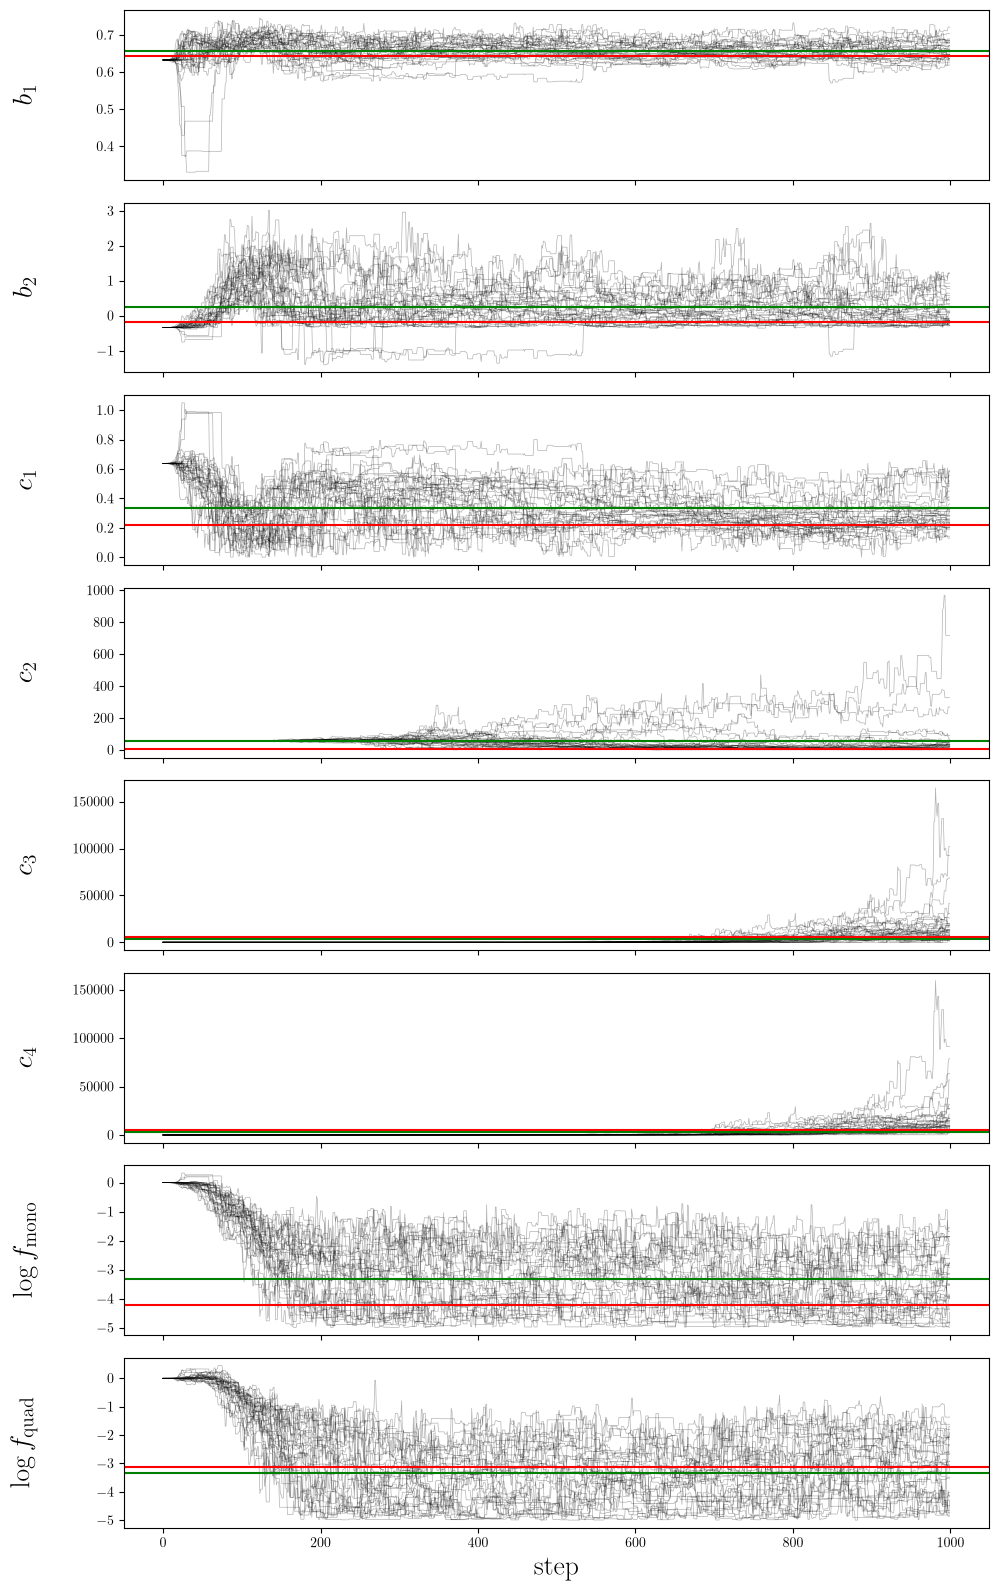

In [41]:

labels = [
    r"$b_1$", r"$b_2$",
    r"$c_1$", r"$c_2$", r"$c_3$", r"$c_4$",
    r"$\log f_{\rm mono}$", r"$\log f_{\rm quad}$", r"$\log f_{\rm hexa}$",
]

chain = mono_quad_sampler.get_chain()  # shape: (nsteps, nwalkers, ndim)
ndim = chain.shape[2]

fig, axes = plt.subplots(ndim, 1, figsize=(10, 2*ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]
    ax.plot(chain[:, :, i], alpha=0.3, color='k', lw=0.5)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.axhline(mono_quad_map_params[i], c='r')
    ax.axhline(mono_quad_mean_params[i], c='g')


axes[-1].set_xlabel("step")
plt.tight_layout()
plt.show()

In [37]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(2160, 9)


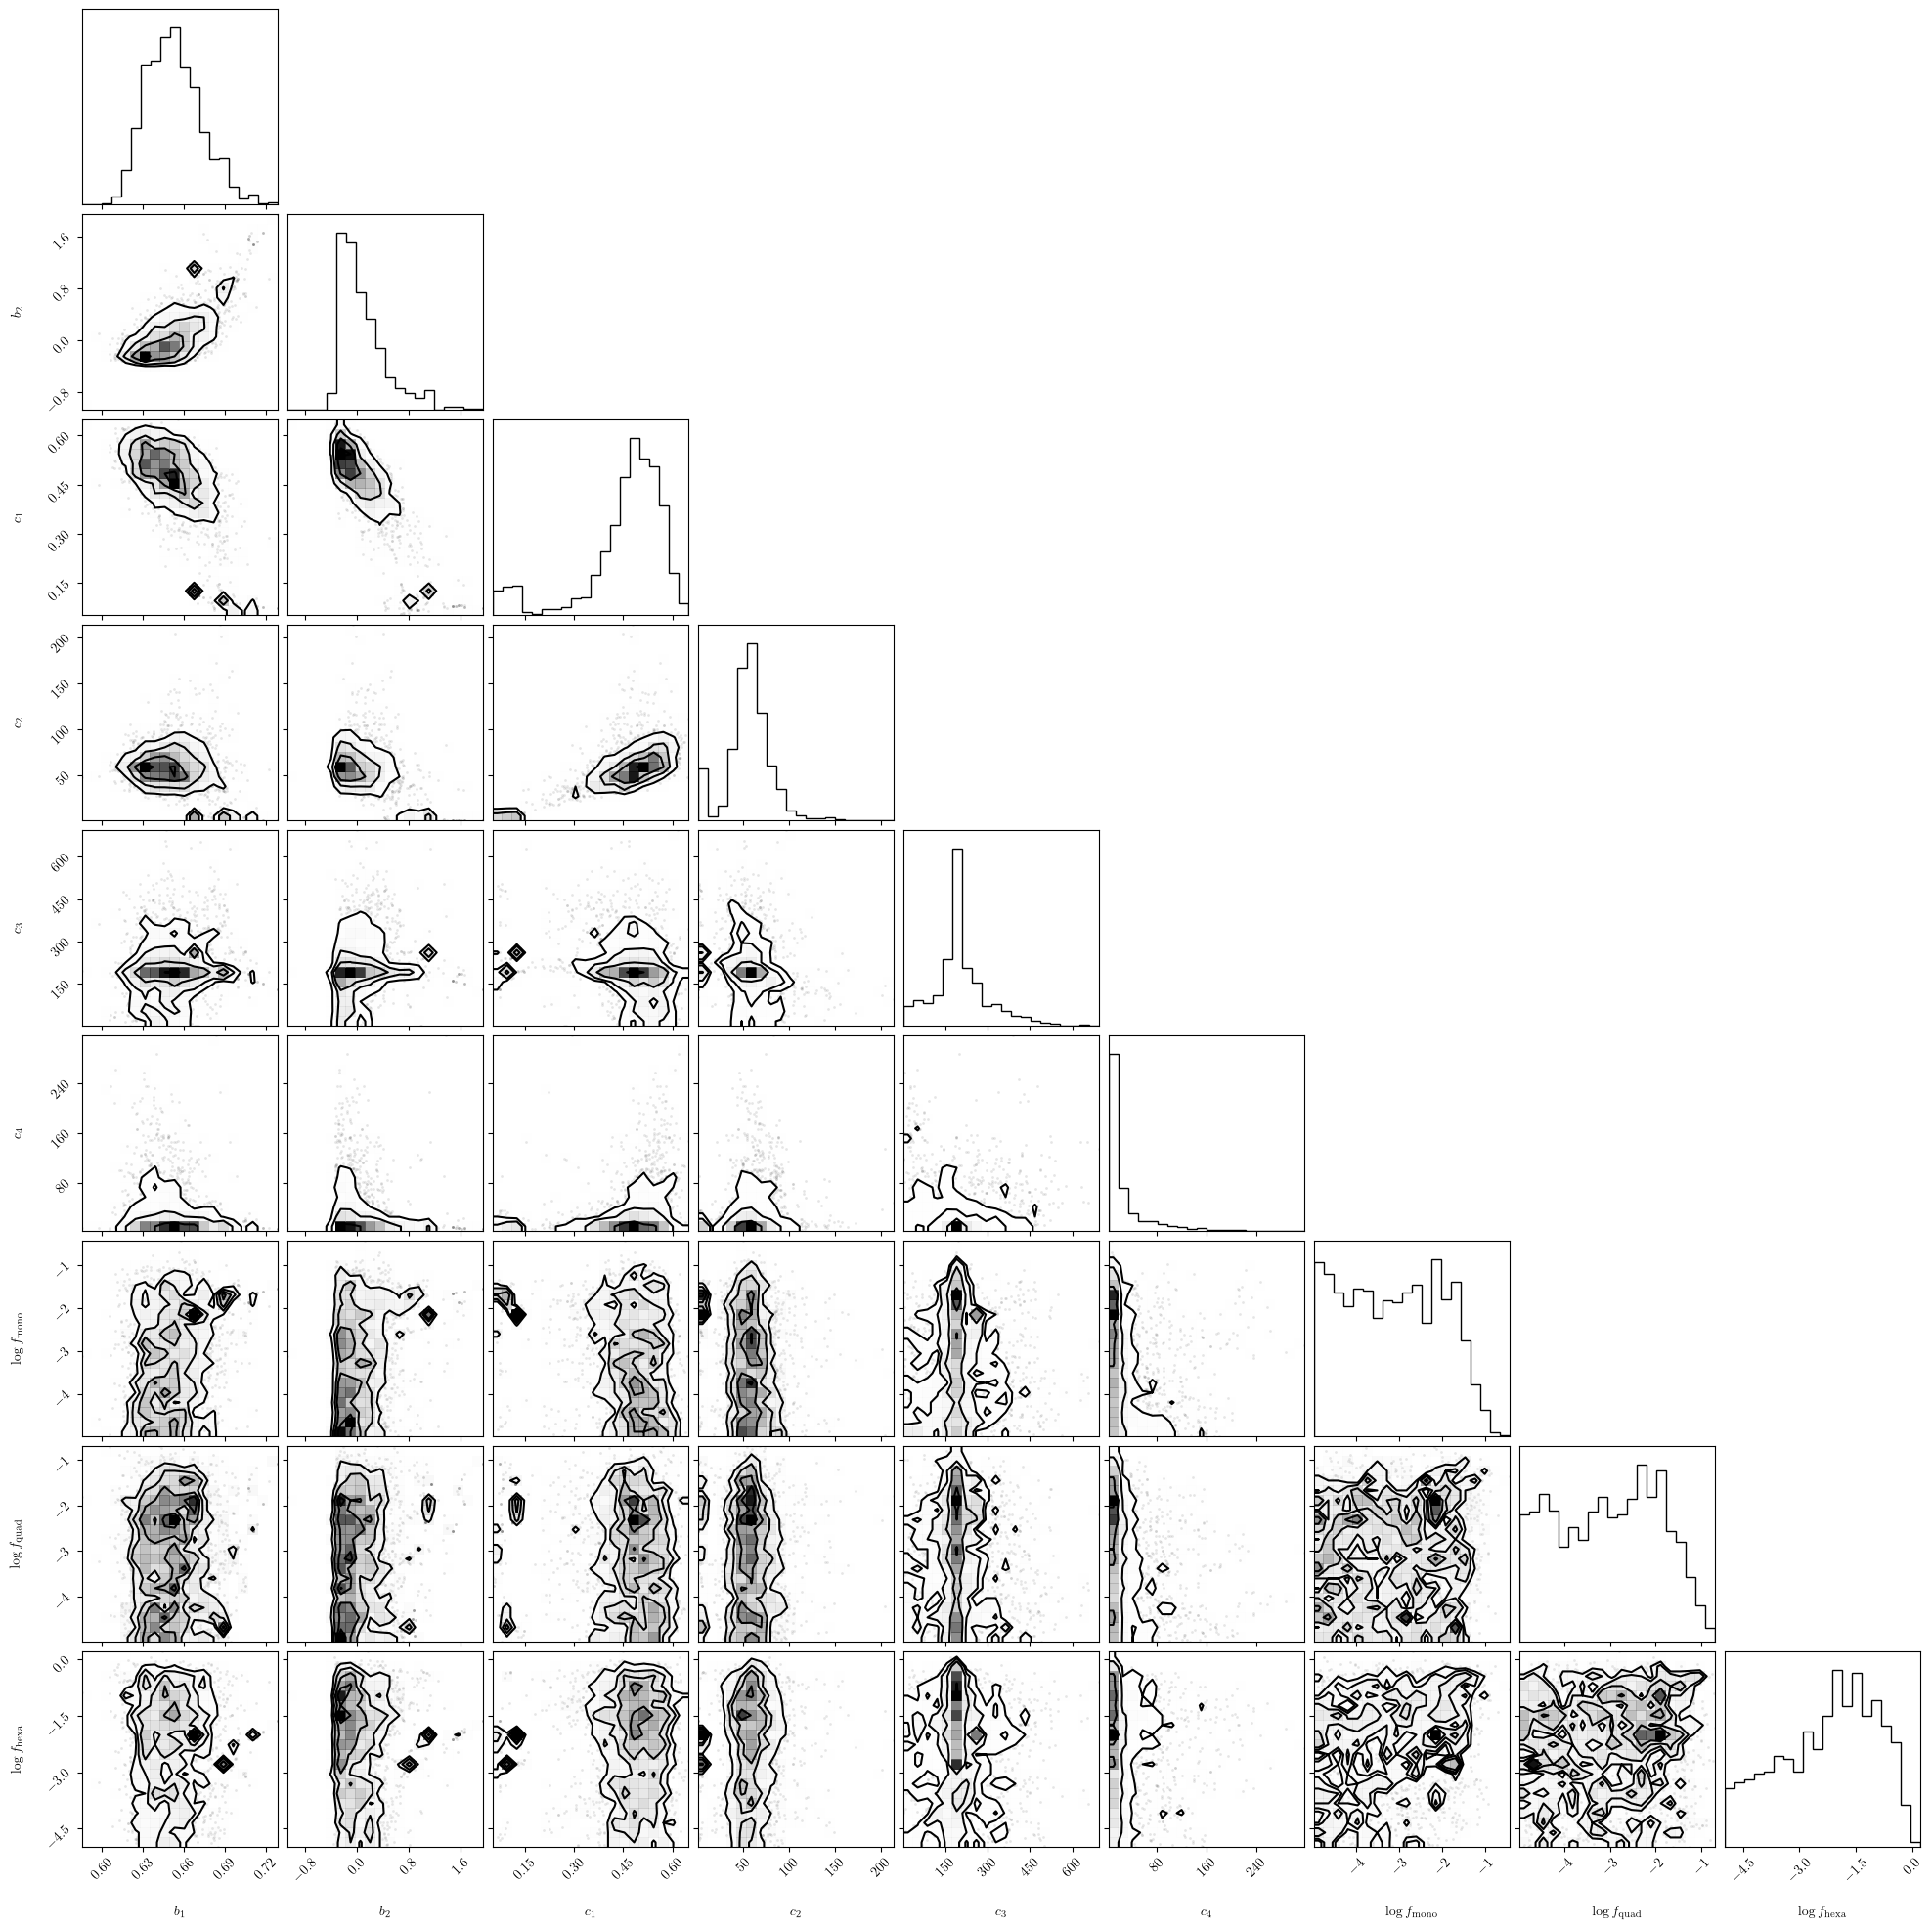

In [62]:
import corner

fig = corner.corner(
    flat_samples, labels=labels,
);